# Machine Learning Course - Setup Instructions

## Environment Setup (ensure you have done it before running the notebook)

### 1. Create a Virtual Environment
First, navigate to the folder where you cloned this repository, then create the virtual environment:
```bash
cd /path/to/modelizacion  # Navigate to the repository folder
python3 -m venv .modelizacion_env
```

The virtual environment `.modelizacion_env` will be created in the same folder as this notebook and `requirements.txt`.

### 2. Activate the Virtual Environment
```bash
source .modelizacion_env/bin/activate
```

### 3. Install Requirements
```bash
pip install -r requirements.txt
```

### 4. Add Environment to Jupyter Kernels
To use this environment in Jupyter, run:
```bash
python -m ipykernel install --user --name=modelizacion --display-name="Python (ML Course)"
```

### 5. Select the Kernel
In Jupyter/VS Code, select the kernel "Python (ML Course)" from the kernel picker (top right).

---

## Notation Convention

### Training Data
- $N$: number of training samples
- $x_n, n=1,\ldots,N$: training input samples, where $x \in \mathbb{R}^d$
- $y_n, n=1,\ldots,N$: training targets/labels
- $d$: input dimension
- $d'$: output dimension

### Features and Model
- $\phi_j(x), j=0,1,\ldots,m-1$: feature functions
- $\Phi$: feature matrix with elements $\Phi_{nj} = \phi_j(x_n)$
- $m$: number of features
- $w$: parameter vector/matrix
- $f(x, w)$: model function

### Classification
- $k$: index for output components in categorical classification (number of classes)
- $K$: total number of classes

### Loss and Predictions
- $L$: loss function
- $\hat{y}$: predictions

In [1]:
# Import all necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score, confusion_matrix
from sklearn.datasets import make_moons, make_circles, load_digits

# Deep learning libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist, cifar10
from tensorflow.keras.utils import to_categorical

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("Libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"TensorFlow version: {tf.__version__}")

I0000 00:00:1774101593.609602  290941 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774101593.609907  290941 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774101593.635334  290941 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Libraries imported successfully!
NumPy version: 2.4.3
TensorFlow version: 2.21.0


I0000 00:00:1774101594.229249  290941 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774101594.229417  290941 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


---
## 1. Linear Regression

Given training data $(x_n, y_n),$ $n=1,\ldots,N$, we want to find parameters $w = (w_0, w_1,\ldots,w_{m-1})^T \in \mathbb{R}^m$ such that the model function

$$f(x, w) = w^T \phi(x),$$

where $\phi(x) = (\phi_0(x), \ldots, \phi_{m-1}(x))^T$ are fixed features, minimises the squared loss

$$L(w) = \frac{1}{N}\sum_{n=1}^N (y_n - f(x_n, w))^2$$
The loss function is can also be rewritten as

$$L(w) = \frac{1}{N}||Y - \Phi w||^2,$$

where $\Phi \in \mathbb{R}^{N \times m}$ is the feature matrix with each row $n$ containing $\phi(x_n) = (\phi_0(x_n), \ldots, \phi_{m-1}(x_n))$, and $Y = (y_1,\ldots,y_N)^T \in \mathbb{R}^{N}$. 

The closed-form solution is:

$$w^* = (\Phi^T\Phi)^{-1}\Phi^T Y$$

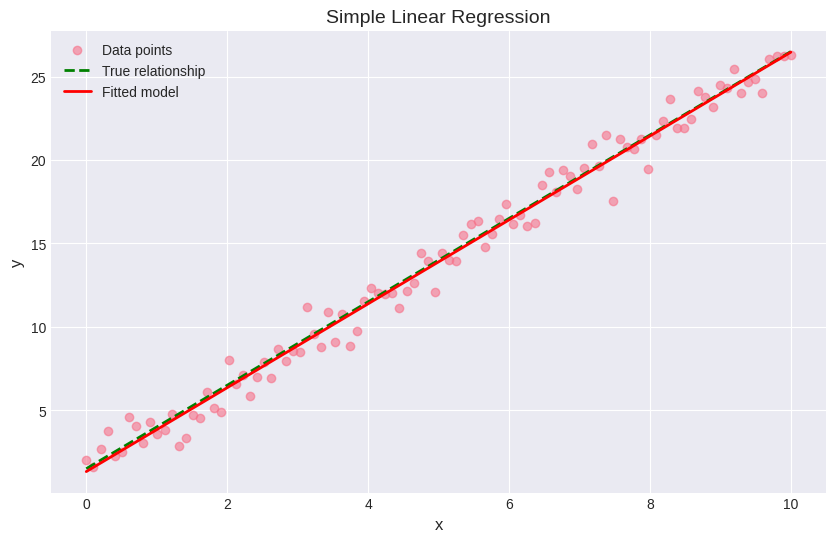

True parameters: w₀ = 1.5, w₁ = 2.5
Fitted parameters: w₀ = 1.327, w₁ = 2.514
MSE: 0.815


In [4]:
# Generate synthetic data
np.random.seed(42)  # For reproducibility
X_simple = np.linspace(0, 10, 100)  # 100 evenly spaced points from 0 to 10
y_true = 2.5 * X_simple + 1.5  # True relationship: y = 2.5x + 1.5
y_noisy = y_true + np.random.normal(0, 1, 100)  # Add Gaussian noise (mean=0, std=2)

# Fit linear regression
X_matrix = X_simple.reshape(-1, 1)  # sklearn requires 2D array: (n_samples, n_features)
model = LinearRegression()  # Create model object
model.fit(X_matrix, y_noisy)  # Learn parameters w₀ and w₁ from data

# Make predictions using learned model
y_pred = model.predict(X_matrix)

# Visualization
plt.figure(figsize=(10, 6))
plt.scatter(X_simple, y_noisy, alpha=0.6, label='Data points')
plt.plot(X_simple, y_true, 'g--', linewidth=2, label='True relationship')
plt.plot(X_simple, y_pred, 'r-', linewidth=2, label='Fitted model')
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Simple Linear Regression', fontsize=14)
plt.legend()
plt.show()

print(f"True parameters: w₀ = 1.5, w₁ = 2.5")
print(f"Fitted parameters: w₀ = {model.intercept_:.3f}, w₁ = {model.coef_[0]:.3f}")
print(f"MSE: {mean_squared_error(y_noisy, y_pred):.3f}")

### Real-World Example: California Housing Prices

Now let's apply linear regression to real data: predicting median house values in California based on location, population, and income.

In [ ]:
# Load the REAL California Housing dataset
from sklearn.datasets import fetch_california_housing

housing_data = fetch_california_housing()  # Download/load dataset from sklearn

# Print official description (stored in housing_data.DESCR)
print(housing_data.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [9]:
X_housing = housing_data.data  # Feature matrix: shape (20640, 8)
y_housing = housing_data.target  # Target vector: median house value in $100,000s
feature_names_housing = housing_data.feature_names  # Names of the 8 features

print("="*70)
print("\n" + "="*70)
print(f"Data structure:")
print(f"  • {X_housing.shape[0]:,} samples × {X_housing.shape[1]} features")
print(f"  • Features: {', '.join(feature_names_housing)}")
print(f"  • Target range: ${y_housing.min()*100:.0f}k - ${y_housing.max()*100:.0f}k")
print(f"\nData types:")
print(f"  • X_housing: {type(X_housing).__name__} with dtype {X_housing.dtype}")
print(f"  • y_housing: {type(y_housing).__name__} with dtype {y_housing.dtype}")
print("="*70)


Data structure:
  • 20,640 samples × 8 features
  • Features: MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude
  • Target range: $15k - $500k

Data types:
  • X_housing: ndarray with dtype float64
  • y_housing: ndarray with dtype float64


In [ ]:
# Visualize the dataset - understand what we're working with
fig, axes = plt.subplots(2, 2, figsize=(16, 12))  # Create 2×2 grid of plots

# Plot 1: Geographic scatter plot (Latitude vs Longitude colored by price)
# X_housing[:, 7] is Longitude, X_housing[:, 6] is Latitude
scatter = axes[0, 0].scatter(X_housing[:, 7], X_housing[:, 6],
                            c=y_housing, cmap='coolwarm',  # Color by price
                            alpha=0.4, s=10)  # Semi-transparent, small dots
axes[0, 0].set_xlabel('Longitude', fontsize=12)
axes[0, 0].set_ylabel('Latitude', fontsize=12)
axes[0, 0].set_title('California Housing Prices (Geographic Distribution)', fontsize=13)
plt.colorbar(scatter, ax=axes[0, 0], label='Price ($100k)')

# Plot 2: Price vs Median Income (strongest predictor)
axes[0, 1].scatter(X_housing[:, 0], y_housing, alpha=0.3, s=10)
axes[0, 1].set_xlabel('Median Income ($10k)', fontsize=12)
axes[0, 1].set_ylabel('House Price ($100k)', fontsize=12)
axes[0, 1].set_title('Price vs Income (Strong Correlation)', fontsize=13)
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Price distribution
axes[1, 0].hist(y_housing, bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('House Price ($100k)', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].set_title('Distribution of House Prices', fontsize=13)
axes[1, 0].axvline(y_housing.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: ${y_housing.mean()*100:.0f}k')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Correlation ranges from -1 (perfect negative) to +1 (perfect positive)
correlations = [np.corrcoef(X_housing[:, i], y_housing)[0, 1] for i in range(8)]
colors_corr = ['green' if c > 0 else 'red' for c in correlations]  # Visual cue
axes[1, 1].barh(feature_names_housing, correlations, color=colors_corr)
axes[1, 1].set_xlabel('Correlation with Price', fontsize=12)
axes[1, 1].set_title('Feature Correlations', fontsize=13)
axes[1, 1].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\nKey Observations:")
print("• You can see the shape of California in the geographic plot!")
print("• Coastal areas (left side) tend to be more expensive")
print(f"• Median income has strongest correlation: {correlations[0]:.3f}")

print("• Most prices are capped at $500k (data collection limit)")print("• Most prices are capped at $500k (data collection limit)")

In [ ]:
# Train linear regression model
print("="*70)
print("Training Linear Regression Model")
print("="*70)

# Split into train and test sets (80/20 split)
# Never train and test on the same data!
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_housing, y_housing, test_size=0.2, random_state=42
)
print(f"Training samples: {X_train_h.shape[0]:,}")
print(f"Test samples:     {X_test_h.shape[0]:,}")

# Standardize features (CRUCIAL when features have different scales!)
# Why? Income ranges from 0-15, but Latitude ranges from 32-42
# Formula: z = (x - μ) / σ  (subtract mean, divide by std)
scaler = StandardScaler()
X_train_h_scaled = scaler.fit_transform(X_train_h)  # Fit on train, transform train
X_test_h_scaled = scaler.transform(X_test_h)  # Only transform test (use train statistics!)

print("\nFeature scaling applied ✓")
# Fit the model using Normal Equation: w* = (X^T X)^(-1) X^T y

housing_model.fit(X_train_h_scaled, y_train_h)  # Finds optimal w_0, w_1, ..., w_8
housing_model = LinearRegression()
housing_model.fit(X_train_h_scaled, y_train_h)


print("\nModel trained successfully!")print(f"Learned {len(housing_model.coef_)} coefficients + 1 intercept")

In [ ]:
# Evaluate the model on test set (unseen data)
y_pred_train_h = housing_model.predict(X_train_h_scaled)
y_pred_test_h = housing_model.predict(X_test_h_scaled)

# R² score: proportion of variance explained (closer to 1 is better)
test_r2 = housing_model.score(X_test_h_scaled, y_test_h)
# MSE: mean squared error (lower is better)
test_mse_h = mean_squared_error(y_test_h, y_pred_test_h)

# Visualize results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Predicted vs Actual
axes[0].scatter(y_test_h, y_pred_test_h, alpha=0.4, s=20)
axes[0].plot([y_test_h.min(), y_test_h.max()],
             [y_test_h.min(), y_test_h.max()],
             'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Price ($100k)', fontsize=12)
axes[0].set_ylabel('Predicted Price ($100k)', fontsize=12)
axes[0].set_title(f'Predictions vs Actual\nR² = {test_r2:.3f}', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)
# Good model → residuals randomly scattered around 0 (no pattern)
residuals = y_test_h - y_pred_test_h
axes[1].scatter(y_pred_test_h, residuals, alpha=0.4, s=20)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)  # Reference line
axes[1].set_xlabel('Predicted Price ($100k)', fontsize=12)
axes[1].set_ylabel('Residual (Actual - Predicted)', fontsize=12)
axes[1].set_title('Residuals\n(should be randomly scattered)', fontsize=13)
axes[1].grid(True, alpha=0.3)
# Plot 3: Feature importance (learned coefficients)
# Larger |coefficient| → stronger influence on price
coefficients = housing_model.coef_  # The learned weights w_1, ..., w_8
sorted_idx = np.argsort(np.abs(coefficients))  # Sort by absolute value
colors = ['green' if coefficients[i] > 0 else 'red' for i in sorted_idx]

axes[2].barh(np.array(feature_names_housing)[sorted_idx],
             coefficients[sorted_idx], color=colors)
axes[2].set_xlabel('Standardized Coefficient', fontsize=12)
axes[2].set_title('Feature Importance\n(Green↑ price, Red↓ price)', fontsize=13)
axes[2].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
axes[2].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("="*70)
print("Model Performance")
print("="*70)
print(f"R² Score:  {test_r2:.4f} (explains {test_r2*100:.1f}% of price variance)")
print(f"RMSE:      ${np.sqrt(test_mse_h)*100:.0f}k (average prediction error)")
print(f"\nMost Important Features:")
top_3_idx = np.argsort(np.abs(coefficients))[-3:][::-1]
for idx in top_3_idx:
    effect = "increases" if coefficients[idx] > 0 else "decreases"
    print(f"  {feature_names_housing[idx]:12s}: {effect} price (coef = {coefficients[idx]:+.3f})")
print("\n✓ Median income is the strongest predictor!")

print("="*70)
print("="*70)
print("\n✓ Median income is the strongest predictor!")print("="*70)

### Polynomial Features: Approximating sin(x)

Key Insight: Linear regression is linear in parameters, not features! We can use polynomial features:

$$f(x, w) = w_0 + w_1 x + w_2 x^2 + \cdots + w_{m-1} x^{m-1}$$

In this case, 

$$\phi(x) = (\phi_0(x),\phi_1(x),\ldots,\phi_{m-1}(x)) = (1, x, x^2,\ldots,x^{m-1})$$

Let's approximate $\sin(x)$ using polynomial features.

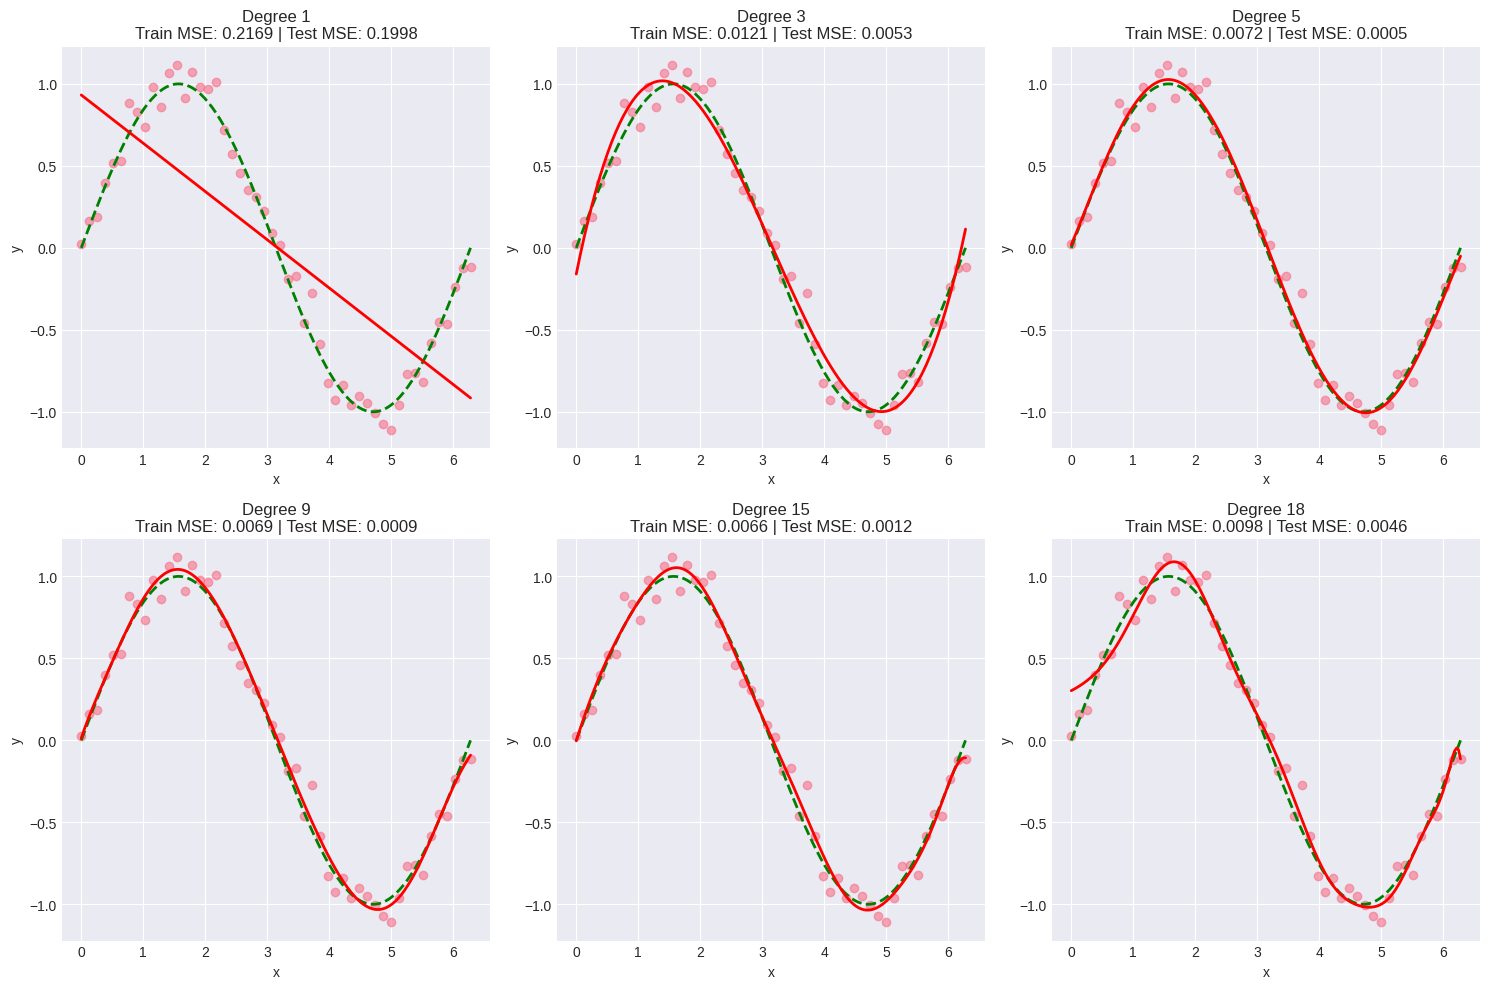

In [4]:
# Generate data from sin(x)
X_sin = np.linspace(0, 2*np.pi, 50).reshape(-1, 1)
y_sin = np.sin(X_sin).ravel() + np.random.normal(0, 0.1, 50)

# Test different polynomial degrees
degrees = [1, 3, 5, 9, 15, 18]
X_test = np.linspace(0, 2*np.pi, 200).reshape(-1, 1)
y_test_true = np.sin(X_test).ravel()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, degree in enumerate(degrees):
    # Create polynomial features: builds design matrix Φ where each row contains φ(x_n)
    # For degree m: φ(x) = (1, x, x², ..., x^m)
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X_sin)  # Φ_train: N_train × (m+1)
    X_test_poly = poly.transform(X_test)  # Φ_test: N_test × (m+1)

    # Fit model using normal equation (exact solution)
    # Note: PolynomialFeatures already includes bias, so fit_intercept=False
    model = LinearRegression(fit_intercept=False)
    model.fit(X_poly, y_sin)
    y_pred = model.predict(X_test_poly)

    # Calculate training MSE (on noisy training data)
    y_train_pred = model.predict(X_poly)
    train_mse = np.mean((y_train_pred - y_sin)**2)

    # Calculate test MSE (comparing to true sin(x) - the underlying function)
    test_mse = np.mean((y_pred - y_test_true)**2)

    # Plot
    axes[idx].scatter(X_sin, y_sin, alpha=0.6, label='Data')
    axes[idx].plot(X_test, y_test_true, 'g--', linewidth=2, label='True sin(x)')
    axes[idx].plot(X_test, y_pred, 'r-', linewidth=2, label=f'Degree {degree}')
    axes[idx].set_xlabel('x')
    axes[idx].set_ylabel('y')
    axes[idx].set_title(f'Degree {degree}\nTrain MSE: {train_mse:.4f} | Test MSE: {test_mse:.4f}')
plt.tight_layout()
plt.show()

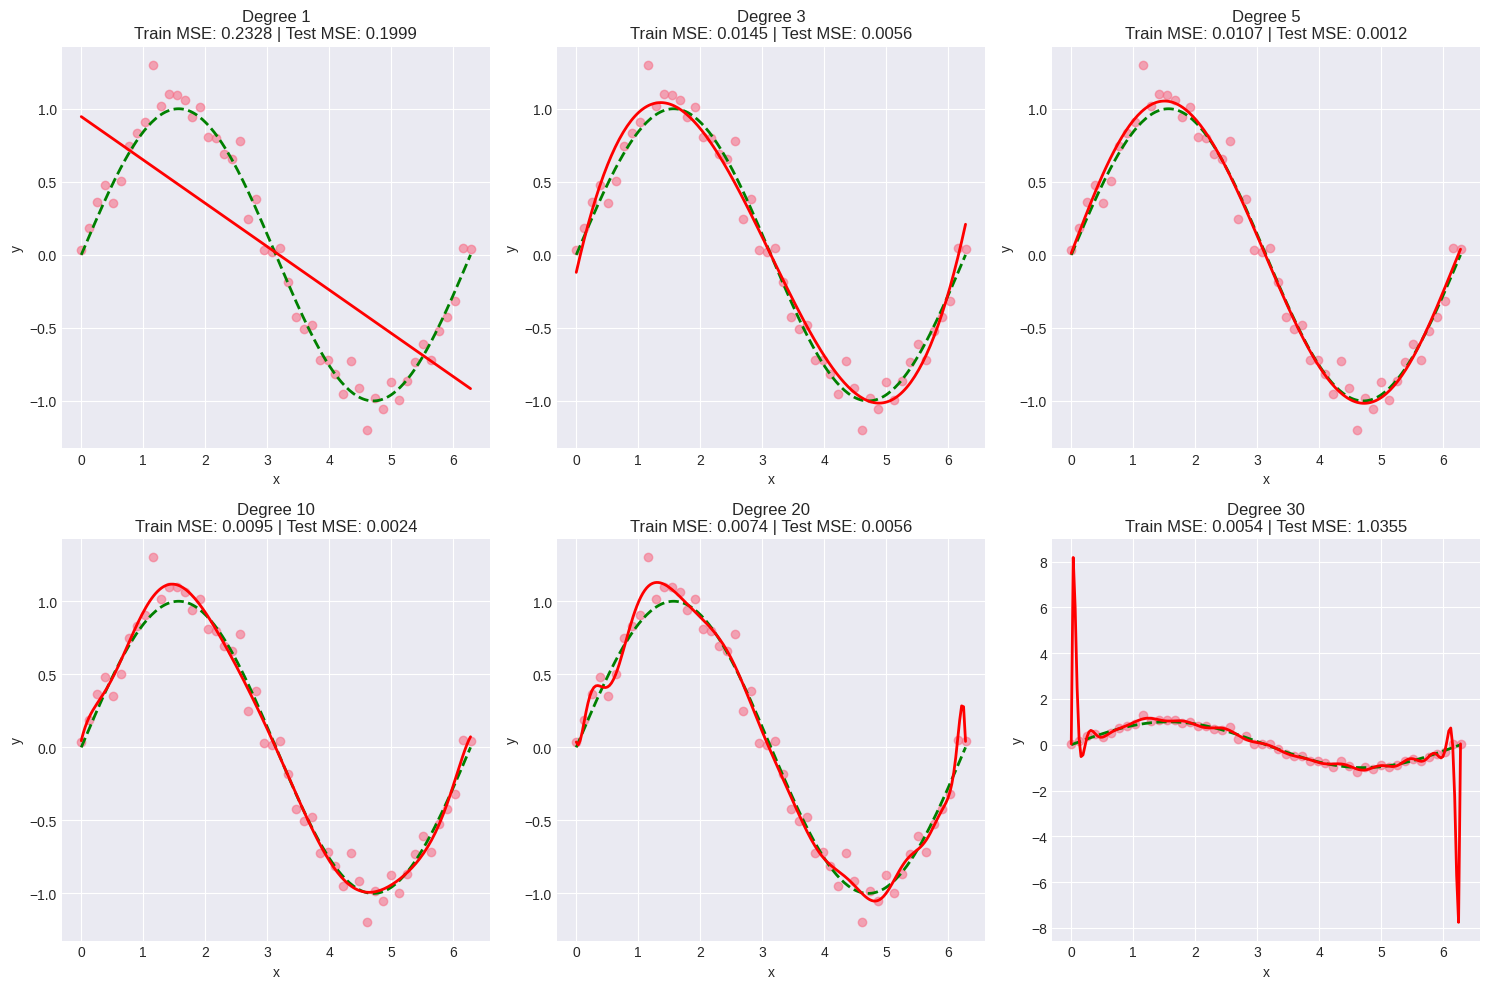

In [5]:
# Same example as above but normalising the data
# Generate data from sin(x)
X_sin = np.linspace(0, 2*np.pi, 50).reshape(-1, 1)
y_sin = np.sin(X_sin).ravel() + np.random.normal(0, 0.1, 50)

# Normalize X to [-1, 1] for numerical stability in high-degree polynomials
X_min, X_max = X_sin.min(), X_sin.max()
X_sin_norm = 2 * (X_sin - X_min) / (X_max - X_min) - 1

# Test different polynomial degrees
degrees = [1, 3, 5, 10, 20, 30]
X_test = np.linspace(0, 2*np.pi, 200).reshape(-1, 1)
X_test_norm = 2 * (X_test - X_min) / (X_max - X_min) - 1
y_test_true = np.sin(X_test).ravel()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, degree in enumerate(degrees):
    # Create polynomial features: builds design matrix Φ where each row contains φ(x_n)
    # For degree m: φ(x) = (1, x, x², ..., x^m)
    # Note: Using normalized x ∈ [-1,1] for numerical stability
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X_sin_norm)  # Φ_train: N_train × (m+1)
    X_test_poly = poly.transform(X_test_norm)  # Φ_test: N_test × (m+1)

    # Fit model using normal equation (exact solution)
    # Note: PolynomialFeatures already includes bias, so fit_intercept=False
    model = LinearRegression(fit_intercept=False)
    model.fit(X_poly, y_sin)
    y_pred = model.predict(X_test_poly)

    # Calculate training MSE (on noisy training data)
    y_train_pred = model.predict(X_poly)
    train_mse = np.mean((y_train_pred - y_sin)**2)

    # Calculate test MSE (comparing to true sin(x) - the underlying function)
    test_mse = np.mean((y_pred - y_test_true)**2)

    # Plot
    axes[idx].scatter(X_sin, y_sin, alpha=0.6, label='Data')
    axes[idx].plot(X_test, y_test_true, 'g--', linewidth=2, label='True sin(x)')
    axes[idx].plot(X_test, y_pred, 'r-', linewidth=2, label=f'Degree {degree}')
    axes[idx].set_xlabel('x')
    axes[idx].set_ylabel('y')
    axes[idx].set_title(f'Degree {degree}\nTrain MSE: {train_mse:.4f} | Test MSE: {test_mse:.4f}')
plt.tight_layout()
plt.show()

### Alternative: Gaussian (RBF) Features

Instead of polynomials, we can use Gaussian basis functions (also called Radial Basis Functions):

$$\phi_i(x) = \exp\left(-\frac{(x - \mu_i)^2}{2\sigma^2}\right)$$

where $\mu_i$ are center points spread across the input space and $\sigma$ controls the width.

Why Gaussian features?
- Better suited for periodic/smooth functions like sin(x)
- More localized influence (each feature affects a local region)
- No numerical stability issues with high dimensions

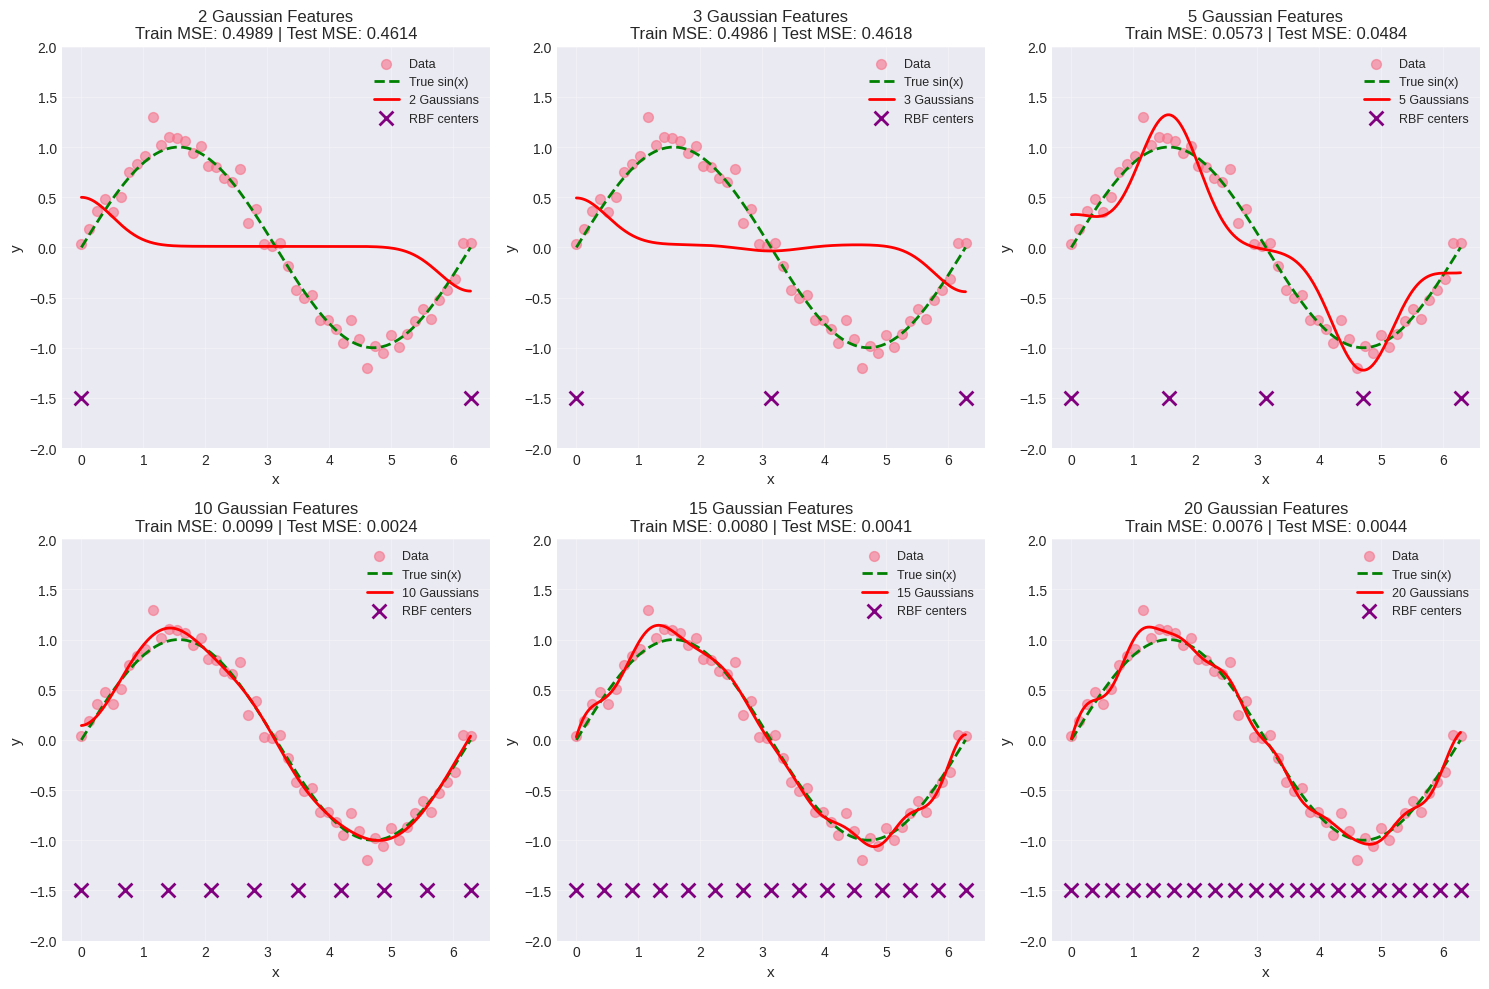

In [6]:
# Create Gaussian/RBF features manually
def gaussian_features(X, centers, sigma=0.3):
    """
    Create Gaussian RBF features: φ_i(x) = exp(-(x - μ_i)²/(2σ²))

    Args:
    - X: input data (N × 1)
    - centers: center points for Gaussian basis functions (m,)
    - sigma: width parameter

    Returns:
    - Φ: design matrix with Gaussian features (N × (m+1)) including bias
    """
    N = X.shape[0]
    m = len(centers)
    Phi = np.zeros((N, m + 1))
    Phi[:, 0] = 1  # Bias term

    for i, mu in enumerate(centers):
        Phi[:, i+1] = np.exp(-((X.ravel() - mu)**2) / (2 * sigma**2))

    return Phi

# Test with different numbers of Gaussian basis functions
n_centers_list = [2, 3, 5, 10, 15, 20]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, n_centers in enumerate(n_centers_list):
    # Place centers uniformly across [0, 2π]
    centers = np.linspace(0, 2*np.pi, n_centers)

    # Create Gaussian features
    Phi_train = gaussian_features(X_sin, centers, sigma=0.5)
    Phi_test = gaussian_features(X_test, centers, sigma=0.5)

    # Fit using normal equation (exact solution)
    model = LinearRegression(fit_intercept=False)
    model.fit(Phi_train, y_sin)
    y_pred = model.predict(Phi_test)

    # Calculate errors
    y_train_pred = model.predict(Phi_train)
    train_mse = np.mean((y_train_pred - y_sin)**2)
    test_mse = np.mean((y_pred - y_test_true)**2)

    # Plot
    axes[idx].scatter(X_sin, y_sin, alpha=0.6, label='Data', s=50)
    axes[idx].plot(X_test, y_test_true, 'g--', linewidth=2, label='True sin(x)')
    axes[idx].plot(X_test, y_pred, 'r-', linewidth=2, label=f'{n_centers} Gaussians')

    # Show Gaussian centers
    axes[idx].scatter(centers, np.zeros_like(centers) - 1.5, marker='x', s=100,
                     c='purple', label='RBF centers', linewidths=2)

    axes[idx].set_xlabel('x', fontsize=11)
    axes[idx].set_ylabel('y', fontsize=11)
    axes[idx].set_title(f'{n_centers} Gaussian Features\nTrain MSE: {train_mse:.4f} | Test MSE: {test_mse:.4f}',
                       fontsize=12)
    axes[idx].legend(fontsize=9)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_ylim(-2, 2)

plt.tight_layout()
plt.show()

---
## 2. The Overfitting Crisis

### Demonstrating Overfitting

Key Problem: Models that are too complex memorize training data but fail to generalize.

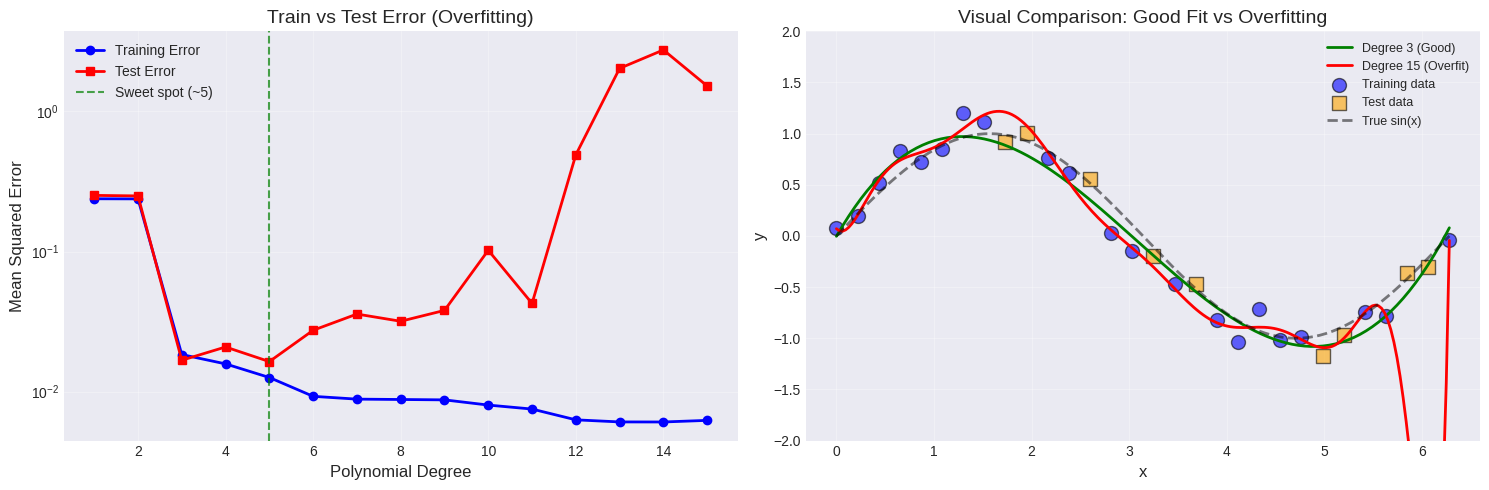

In [7]:
# Generate data with train/test split
np.random.seed(42)
X_full = np.linspace(0, 2*np.pi, 30).reshape(-1, 1)
y_full = np.sin(X_full).ravel() + np.random.normal(0, 0.15, 30)

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.3, random_state=42)

# Sort for visualization
train_idx = np.argsort(X_train.ravel())
test_idx = np.argsort(X_test.ravel())

# Test many polynomial degrees
degrees = range(1, 16)
train_errors = []
test_errors = []

for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    train_mse = mean_squared_error(y_train, model.predict(X_train_poly))
    test_mse = mean_squared_error(y_test, model.predict(X_test_poly))

    train_errors.append(train_mse)
    test_errors.append(test_mse)

# Plot learning curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Left plot: Train vs Test Error
ax1.plot(degrees, train_errors, 'b-o', label='Training Error', linewidth=2)
ax1.plot(degrees, test_errors, 'r-s', label='Test Error', linewidth=2)
ax1.axvline(x=5, color='g', linestyle='--', alpha=0.7, label='Sweet spot (~5)')
ax1.set_xlabel('Polynomial Degree', fontsize=12)
ax1.set_ylabel('Mean Squared Error', fontsize=12)
ax1.set_title('Train vs Test Error (Overfitting)', fontsize=14)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

# Right plot: Show overfitting visually
X_plot = np.linspace(0, 2*np.pi, 200).reshape(-1, 1)
y_plot_true = np.sin(X_plot).ravel()

for degree, color, label in [(3, 'green', 'Degree 3 (Good)'),
                              (15, 'red', 'Degree 15 (Overfit)')]:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_plot_poly = poly.transform(X_plot)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    y_pred = model.predict(X_plot_poly)

    ax2.plot(X_plot, y_pred, color=color, linewidth=2, label=label)

ax2.scatter(X_train, y_train, c='blue', s=100, alpha=0.6, edgecolors='black', label='Training data')
ax2.scatter(X_test, y_test, c='orange', s=100, alpha=0.6, edgecolors='black', marker='s', label='Test data')
ax2.plot(X_plot, y_plot_true, 'k--', linewidth=2, alpha=0.5, label='True sin(x)')
ax2.set_xlabel('x', fontsize=12)
ax2.set_ylabel('y', fontsize=12)
ax2.set_title('Visual Comparison: Good Fit vs Overfitting', fontsize=14)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(-2, 2)

plt.tight_layout()
plt.show()

---
## 3. Regularization to the Rescue

### L² Regularization (Ridge Regression)

Add a penalty term to prevent large weights:

$$L_{\text{ridge}}(w) = \frac{1}{N}||Y - \Phi w||^2 + \lambda||w||^2$$

The exact solution becomes:

$$w^* = (\Phi^T \Phi + \lambda I)^{-1} \Phi^T y$$

/home/aythami-beth/ml/modelizacion/.modelizacion_env/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.0257537762397479e-23.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


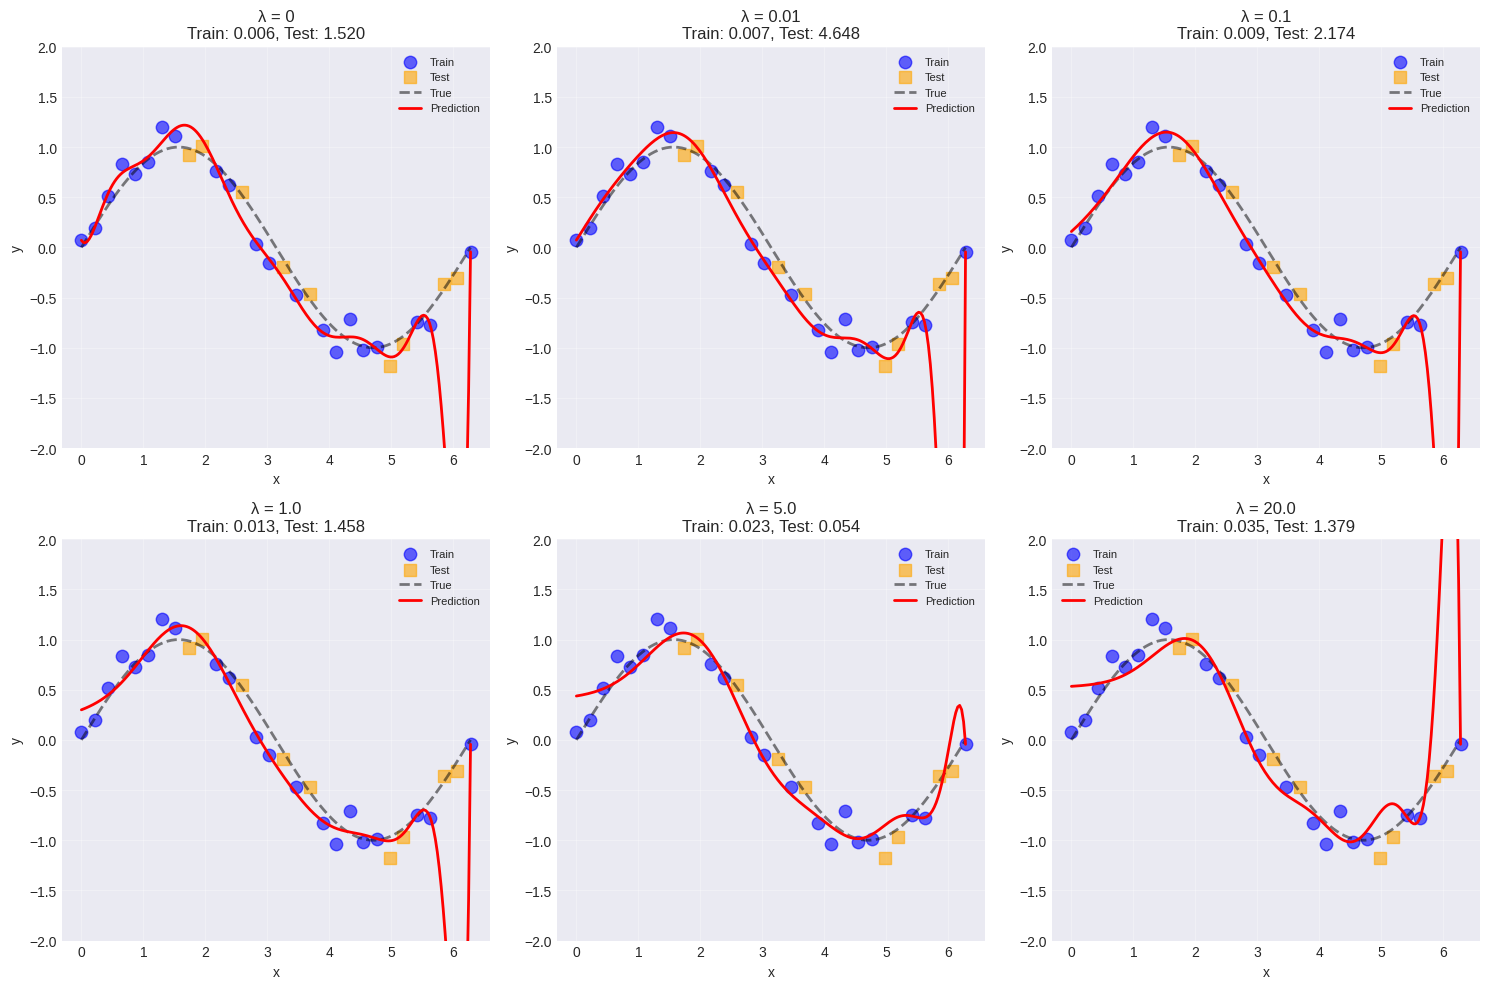

In [8]:
# High-degree polynomial with and without regularization
degree = 15
poly = PolynomialFeatures(degree=degree)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
X_plot_poly = poly.transform(X_plot)

# Test different regularization strengths
alphas = [0, 0.01, 0.1, 1.0, 5.0, 20.0]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

weights_history = []

for idx, alpha in enumerate(alphas):
    if alpha == 0:
        model = LinearRegression()
    else:
        model = Ridge(alpha=alpha)

    model.fit(X_train_poly, y_train)
    y_pred_train = model.predict(X_train_poly)
    y_pred_test = model.predict(X_test_poly)
    y_pred_plot = model.predict(X_plot_poly)

    train_mse = mean_squared_error(y_train, y_pred_train)
    test_mse = mean_squared_error(y_test, y_pred_test)

    # Store coefficients
    weights_history.append(model.coef_ if hasattr(model, 'coef_') else None)

    # Plot
    axes[idx].scatter(X_train, y_train, c='blue', s=80, alpha=0.6, label='Train')
    axes[idx].scatter(X_test, y_test, c='orange', s=80, alpha=0.6, marker='s', label='Test')
    axes[idx].plot(X_plot, y_plot_true, 'k--', linewidth=2, alpha=0.5, label='True')
    axes[idx].plot(X_plot, y_pred_plot, 'r-', linewidth=2, label='Prediction')
    axes[idx].set_ylim(-2, 2)
    axes[idx].set_xlabel('x')
    axes[idx].set_ylabel('y')
    axes[idx].set_title(f'λ = {alpha}\nTrain: {train_mse:.3f}, Test: {test_mse:.3f}')
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Coefficient Shrinkage

Let's visualize how regularization shrinks the coefficients.

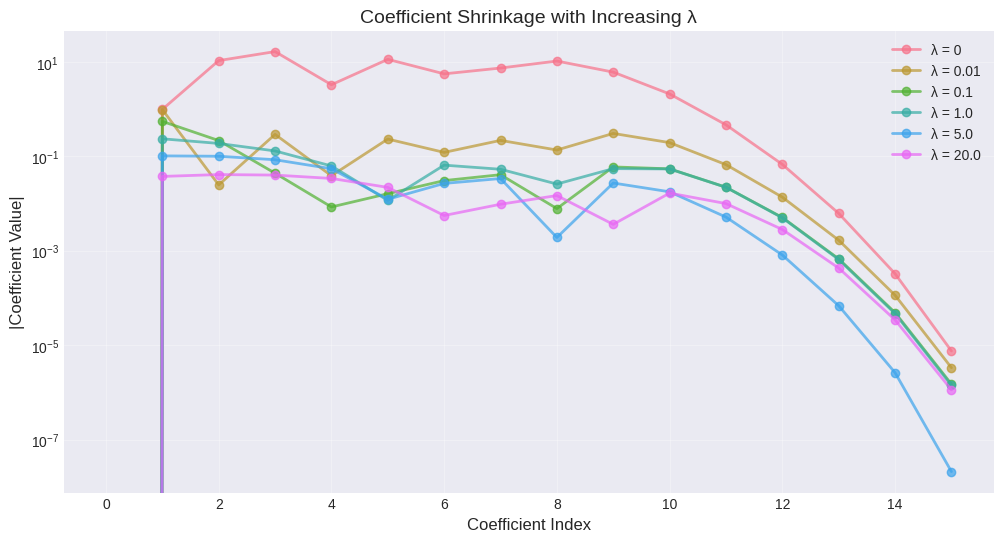

In [9]:
# Visualize coefficient magnitudes
plt.figure(figsize=(12, 6))

for idx, (alpha, weights) in enumerate(zip(alphas, weights_history)):
    if weights is not None:
        plt.plot(range(len(weights)), np.abs(weights), 'o-',
                label=f'λ = {alpha}', alpha=0.7, linewidth=2)

plt.xlabel('Coefficient Index', fontsize=12)
plt.ylabel('|Coefficient Value|', fontsize=12)
plt.title('Coefficient Shrinkage with Increasing λ', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.show()

### Cross-Validation for Hyperparameter Selection

How do we choose the best $\lambda$? Use cross-validation!

/home/aythami-beth/ml/modelizacion/.modelizacion_env/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 4.398717060722988e-29.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/aythami-beth/ml/modelizacion/.modelizacion_env/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 9.457128787039895e-29.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/aythami-beth/ml/modelizacion/.modelizacion_env/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.628887398768363e-27.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/aythami-beth/ml/modelizacion/.modelizacion_env/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: 

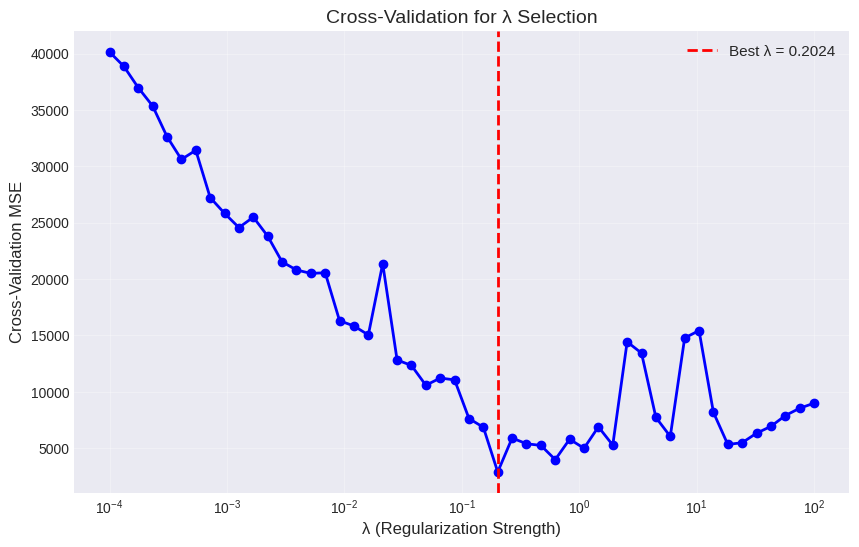


Best λ = 0.2024
Cross-validation MSE at best λ = 2885.7856


In [10]:
# Test many lambda values with cross-validation
alphas_test = np.logspace(-4, 2, 50)
cv_scores = []

for alpha in alphas_test:
    model = Ridge(alpha=alpha)
    scores = cross_val_score(model, X_train_poly, y_train,
                            cv=5, scoring='neg_mean_squared_error')
    cv_scores.append(-scores.mean())

# Find best alpha
best_alpha = alphas_test[np.argmin(cv_scores)]

plt.figure(figsize=(10, 6))
plt.plot(alphas_test, cv_scores, 'b-o', linewidth=2)
plt.axvline(best_alpha, color='r', linestyle='--', linewidth=2,
           label=f'Best λ = {best_alpha:.4f}')
plt.xlabel('λ (Regularization Strength)', fontsize=12)
plt.ylabel('Cross-Validation MSE', fontsize=12)
plt.title('Cross-Validation for λ Selection', fontsize=14)
plt.xscale('log')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nBest λ = {best_alpha:.4f}")
print(f"Cross-validation MSE at best λ = {min(cv_scores):.4f}")

---
## 4. Gradient Descent from Scratch

Instead of the closed-form solution, we can minimize the loss iteratively:

$$w^{(t+1)} = w^{(t)} - \eta \nabla L(w^{(t)})$$

where $\eta$ is the learning rate (step size).

### Deriving the Gradient

For mean squared error loss: $L(w) = \frac{1}{N}\sum_{i=1}^{N}(y_i - \phi_i^T w)^2$

We can write this in matrix form: $L(w) = \frac{1}{N}||y - \Phi w||^2$

Taking the gradient with respect to $w$:

$$\nabla L(w) = \nabla_w \left[\frac{1}{N}(y - \Phi w)^T(y - \Phi w)\right]$$

Factor out the constant $\frac{1}{N}$:

$$= \frac{1}{N} \nabla_w \left[(y - \Phi w)^T(y - \Phi w)\right]$$

Expand the quadratic:

$$= \frac{1}{N} \nabla_w \left[y^Ty - 2y^T\Phi w + w^T\Phi^T\Phi w\right]$$

Take the gradient (note: $\nabla_w(w^TAw) = 2Aw$ for symmetric $A$):

$$= \frac{1}{N}(-2\Phi^Ty + 2\Phi^T\Phi w)$$

Factor out 2 and simplify:

$$= \frac{2}{N}\Phi^T(\Phi w - y) = -\frac{2}{N}\Phi^T(y - \Phi w)$$

This tells us which direction to move $w$ to decrease the loss!

In [20]:
# Note for me: It took me a lot of iteration to make the damn vanilla GD converge!
def gradient_descent_linear_regression(Phi, y, learning_rate=0.01, n_iterations=1000, verbose=False):
    """
    Implement gradient descent for linear regression.

    Parameters:
    - Phi: design matrix (n_samples, n_features+1) - already includes bias!
    - y: target vector (n_samples,)
    - learning_rate: η (step size) - how far to move in direction of gradient
    - n_iterations: number of iterations to run

    Returns:
    - w: learned parameters
    - loss_history: loss at each iteration
    """
    n_samples, n_features = Phi.shape

    # Initialize parameters to zero
    w = np.zeros(n_features)
    loss_history = []

    for iteration in range(n_iterations):
        # 1. Forward pass: compute predictions
        y_pred = Phi @ w

        # 2. Compute loss (Mean Squared Error)
        loss = np.mean((y - y_pred)**2)
        loss_history.append(loss)

        # 3. Compute gradient: ∇L = -(2/N)Φ^T(y - Φw)
        gradient = -(2/n_samples) * Phi.T @ (y - y_pred)

        # 4. Update parameters: move in opposite direction of gradient
        w = w - learning_rate * gradient

        # Optional: print progress
        if verbose and iteration % 200 == 0:
            print(f"Iteration {iteration}: Loss = {loss:.6f}")

    return w, loss_history


def normal_equation_solution(Phi, y):
    """
    Solve linear regression using the closed-form normal equation.

    Formula: w = (Φ^T Φ)^(-1) Φ^T y

    This is exact but requires matrix inversion (expensive for large datasets).

    Parameters:
    - Phi: design matrix (n_samples, n_features+1) - already includes bias!
    - y: target vector (n_samples,)

    Returns:
    - w: optimal parameters
    """
    # Compute w = (Φ^T Φ)^(-1) Φ^T y
    w = np.linalg.inv(Phi.T @ Phi) @ Phi.T @ y

    return w


# =============================================================================
# Apply Gradient Descent to Gaussian RBF Features (Non-trivial problem!)
# =============================================================================

# Use the sin(x) data from earlier with Gaussian basis functions
# This is a realistic problem with 11 parameters (1 bias + 10 Gaussian features)
print("Setting up Gaussian RBF features for approximating sin(x)...")

# Create 10 Gaussian basis function centers
n_centers = 10
centers = np.linspace(0, 2*np.pi, n_centers)
sigma = 0.5

# Create design matrices with Gaussian features
Phi_train = gaussian_features(X_sin, centers, sigma)  # (50 samples, 11 features)
Phi_test = gaussian_features(X_test, centers, sigma)  # (200 samples, 11 features)

print(f"Design matrix shape: {Phi_train.shape} (N={Phi_train.shape[0]} samples, M={Phi_train.shape[1]} features)")
print(f"Learning {Phi_train.shape[1]} parameters (1 bias + {n_centers} Gaussian weights)\n")

# Method 1: Gradient Descent (iterative optimization)
# Learning rate η = 0.5 chosen empirically for this problem:
# - Features are well-scaled (Gaussian outputs in [0,1])
# - Higher learning rate needed for fast convergence
# - This smooth loss landscape allows aggressive steps
print("="*60)
print("Method 1: Gradient Descent")
print("="*60)
w_gd, loss_history = gradient_descent_linear_regression(
    Phi_train, y_sin,
    learning_rate=0.5,    # Aggressive learning rate for faster convergence
    n_iterations=100000,    # More iterations to reach optimum
    verbose=True
)

# Method 2: Normal Equation (direct solution)
print(f"\n{'='*60}")
print("Method 2: Normal Equation (Closed-form)")
print("="*60)
w_ne = normal_equation_solution(Phi_train, y_sin)
print("Computed in one step (matrix inversion)")

# Compare results
param_diff = np.linalg.norm(w_gd - w_ne)
loss_gd = loss_history[-1]
loss_ne = np.mean((y_sin - Phi_train @ w_ne)**2)

print(f"\n{'='*60}")
print("Results Comparison")
print("="*60)
print(f"Parameter difference (L2): {param_diff:.10f}")
print(f"Final GD loss:            {loss_gd:.10f}")
print(f"Normal equation loss:     {loss_ne:.10f}")
print(f"Loss difference:          {abs(loss_gd - loss_ne):.10e}")
print("="*60)

# Check if actually converged
if param_diff < 1e-4:
    print("\n✓ Gradient descent converged to the same solution!")
elif param_diff < 1e-2:
    print("\n⚠ Gradient descent nearly converged (close but not exact)")
    print("  → Try more iterations or higher learning rate for exact convergence")
else:
    print("\n✗ Gradient descent has NOT converged yet!")
    print(f"  → Parameter difference is {param_diff:.4f} (should be < 0.0001)")
    print("  → Need more iterations or better learning rate")

print(f"\nLearned {len(w_gd)} parameters to approximate sin(x)")

Setting up Gaussian RBF features for approximating sin(x)...
Design matrix shape: (50, 11) (N=50 samples, M=11 features)
Learning 11 parameters (1 bias + 10 Gaussian weights)

Method 1: Gradient Descent
Iteration 0: Loss = 0.533754
Iteration 200: Loss = 0.009998
Iteration 400: Loss = 0.009984
Iteration 600: Loss = 0.009981
Iteration 800: Loss = 0.009978
Iteration 1000: Loss = 0.009976
Iteration 1200: Loss = 0.009973
Iteration 1400: Loss = 0.009971
Iteration 1600: Loss = 0.009969
Iteration 1800: Loss = 0.009967
Iteration 2000: Loss = 0.009964
Iteration 2200: Loss = 0.009962
Iteration 2400: Loss = 0.009960
Iteration 2600: Loss = 0.009958
Iteration 2800: Loss = 0.009956
Iteration 3000: Loss = 0.009954
Iteration 3200: Loss = 0.009952
Iteration 3400: Loss = 0.009950
Iteration 3600: Loss = 0.009948
Iteration 3800: Loss = 0.009947
Iteration 4000: Loss = 0.009945
Iteration 4200: Loss = 0.009943
Iteration 4400: Loss = 0.009941
Iteration 4600: Loss = 0.009940
Iteration 4800: Loss = 0.009938
Iter

### Convergence Visualization

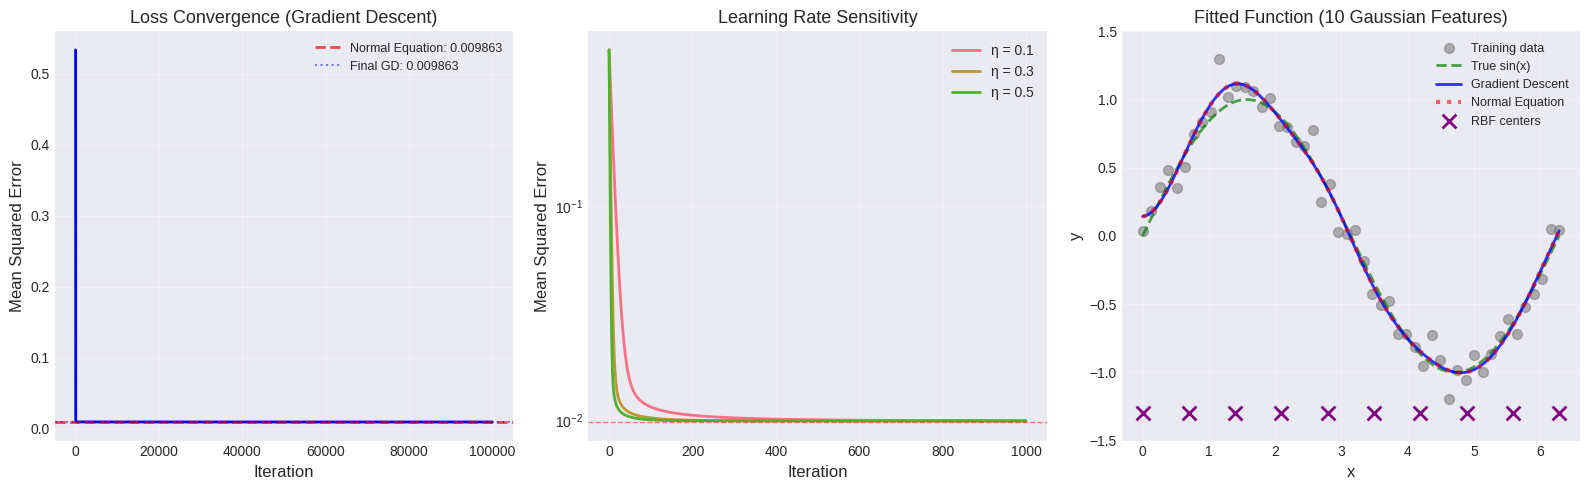

In [29]:
fig = plt.figure(figsize=(16, 5))

# Left: Loss convergence
ax1 = plt.subplot(1, 3, 1)
ax1.plot(loss_history, linewidth=2, color='blue')
ax1.set_xlabel('Iteration', fontsize=12)
ax1.set_ylabel('Mean Squared Error', fontsize=12)
ax1.set_title('Loss Convergence (Gradient Descent)', fontsize=13)
ax1.grid(True, alpha=0.3)

# Show the optimal loss from normal equation
ax1.axhline(y=loss_ne, color='red', linestyle='--', alpha=0.7, linewidth=2,
           label=f'Normal Equation: {loss_ne:.6f}')
ax1.axhline(y=loss_gd, color='blue', linestyle=':', alpha=0.5,
           label=f'Final GD: {loss_gd:.6f}')
ax1.legend(fontsize=9)

# Middle: Effect of learning rate
ax2 = plt.subplot(1, 3, 2)
learning_rates = [0.1, 0.3, 0.5]
for lr in learning_rates:
    _, loss_hist = gradient_descent_linear_regression(
        Phi_train, y_sin, learning_rate=lr, n_iterations=1000, verbose=False
    )
    ax2.plot(loss_hist, label=f'η = {lr}', linewidth=2)

# Show optimal loss
ax2.axhline(y=loss_ne, color='red', linestyle='--', alpha=0.5, linewidth=1)

ax2.set_xlabel('Iteration', fontsize=12)
ax2.set_ylabel('Mean Squared Error', fontsize=12)
ax2.set_title('Learning Rate Sensitivity', fontsize=13)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_yscale('log')

# Right: Fitted function comparison
ax3 = plt.subplot(1, 3, 3)

# Create test grid for smooth visualization (don't rely on potentially stale X_test)
X_test_viz = np.linspace(0, 2*np.pi, 200).reshape(-1, 1)
y_test_viz_true = np.sin(X_test_viz).ravel()

# Recompute design matrix with Gaussian features for this test grid
Phi_test_viz = gaussian_features(X_test_viz, centers, sigma)

# Get predictions on this test grid
y_pred_gd = Phi_test_viz @ w_gd
y_pred_ne = Phi_test_viz @ w_ne

ax3.scatter(X_sin, y_sin, alpha=0.6, s=50, label='Training data', color='gray')
ax3.plot(X_test_viz, y_test_viz_true, 'g--', linewidth=2, label='True sin(x)', alpha=0.7)
ax3.plot(X_test_viz, y_pred_gd, 'b-', linewidth=2, label='Gradient Descent', alpha=0.8)
ax3.plot(X_test_viz, y_pred_ne, 'r:', linewidth=3, label='Normal Equation', alpha=0.6)

# Show Gaussian centers
ax3.scatter(centers, np.zeros_like(centers) - 1.3, marker='x', s=100,
           c='purple', label='RBF centers', linewidths=2, zorder=5)

ax3.set_xlabel('x', fontsize=12)
ax3.set_ylabel('y', fontsize=12)
ax3.set_title(f'Fitted Function ({n_centers} Gaussian Features)', fontsize=13)
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.set_ylim(-1.5, 1.5)

plt.tight_layout()
plt.show()

---
## 5. Binary Classification

### Why Linear Regression Fails for Classification

For binary classification ($y \in \{0, 1\}$), linear regression is problematic:
- Predictions can be $< 0$ or $> 1$
- Not probabilistic

Solution: Logistic regression with sigmoid activation:

$$f(x, w) = \sigma(w^Tx) = \frac{1}{1 + e^{-w^Tx}}$$

Binary Cross-Entropy Loss:

$$L(w) = -\frac{1}{N}\sum_{n=1}^N \left[y_n\log(\hat{y}_n) + (1-y_n)\log(1-\hat{y}_n)\right]$$

### Sigmoid Function Visualization

/home/aythami-beth/ml/modelizacion/.modelizacion_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


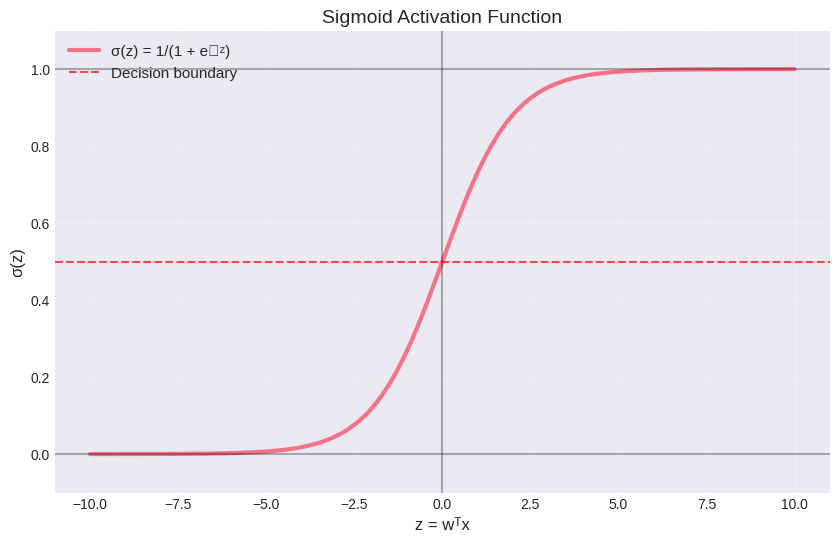

In [30]:
# Visualize sigmoid function
z = np.linspace(-10, 10, 200)
sigmoid = 1 / (1 + np.exp(-z))

plt.figure(figsize=(10, 6))
plt.plot(z, sigmoid, linewidth=3, label='σ(z) = 1/(1 + e⁻ᶻ)')
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.7, label='Decision boundary')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axhline(y=1, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
plt.xlabel('z = wᵀx', fontsize=12)
plt.ylabel('σ(z)', fontsize=12)
plt.title('Sigmoid Activation Function', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.ylim(-0.1, 1.1)
plt.show()

---
## 6. Multi-class Classification: MNIST

### Loading MNIST Dataset

MNIST: 70,000 handwritten digits (28×28 grayscale images)

Training set: (60000, 28, 28)
Test set: (10000, 28, 28)
Pixel range: [0, 255]


Training set: (60000, 28, 28)
Test set: (10000, 28, 28)
Pixel range: [0, 255]


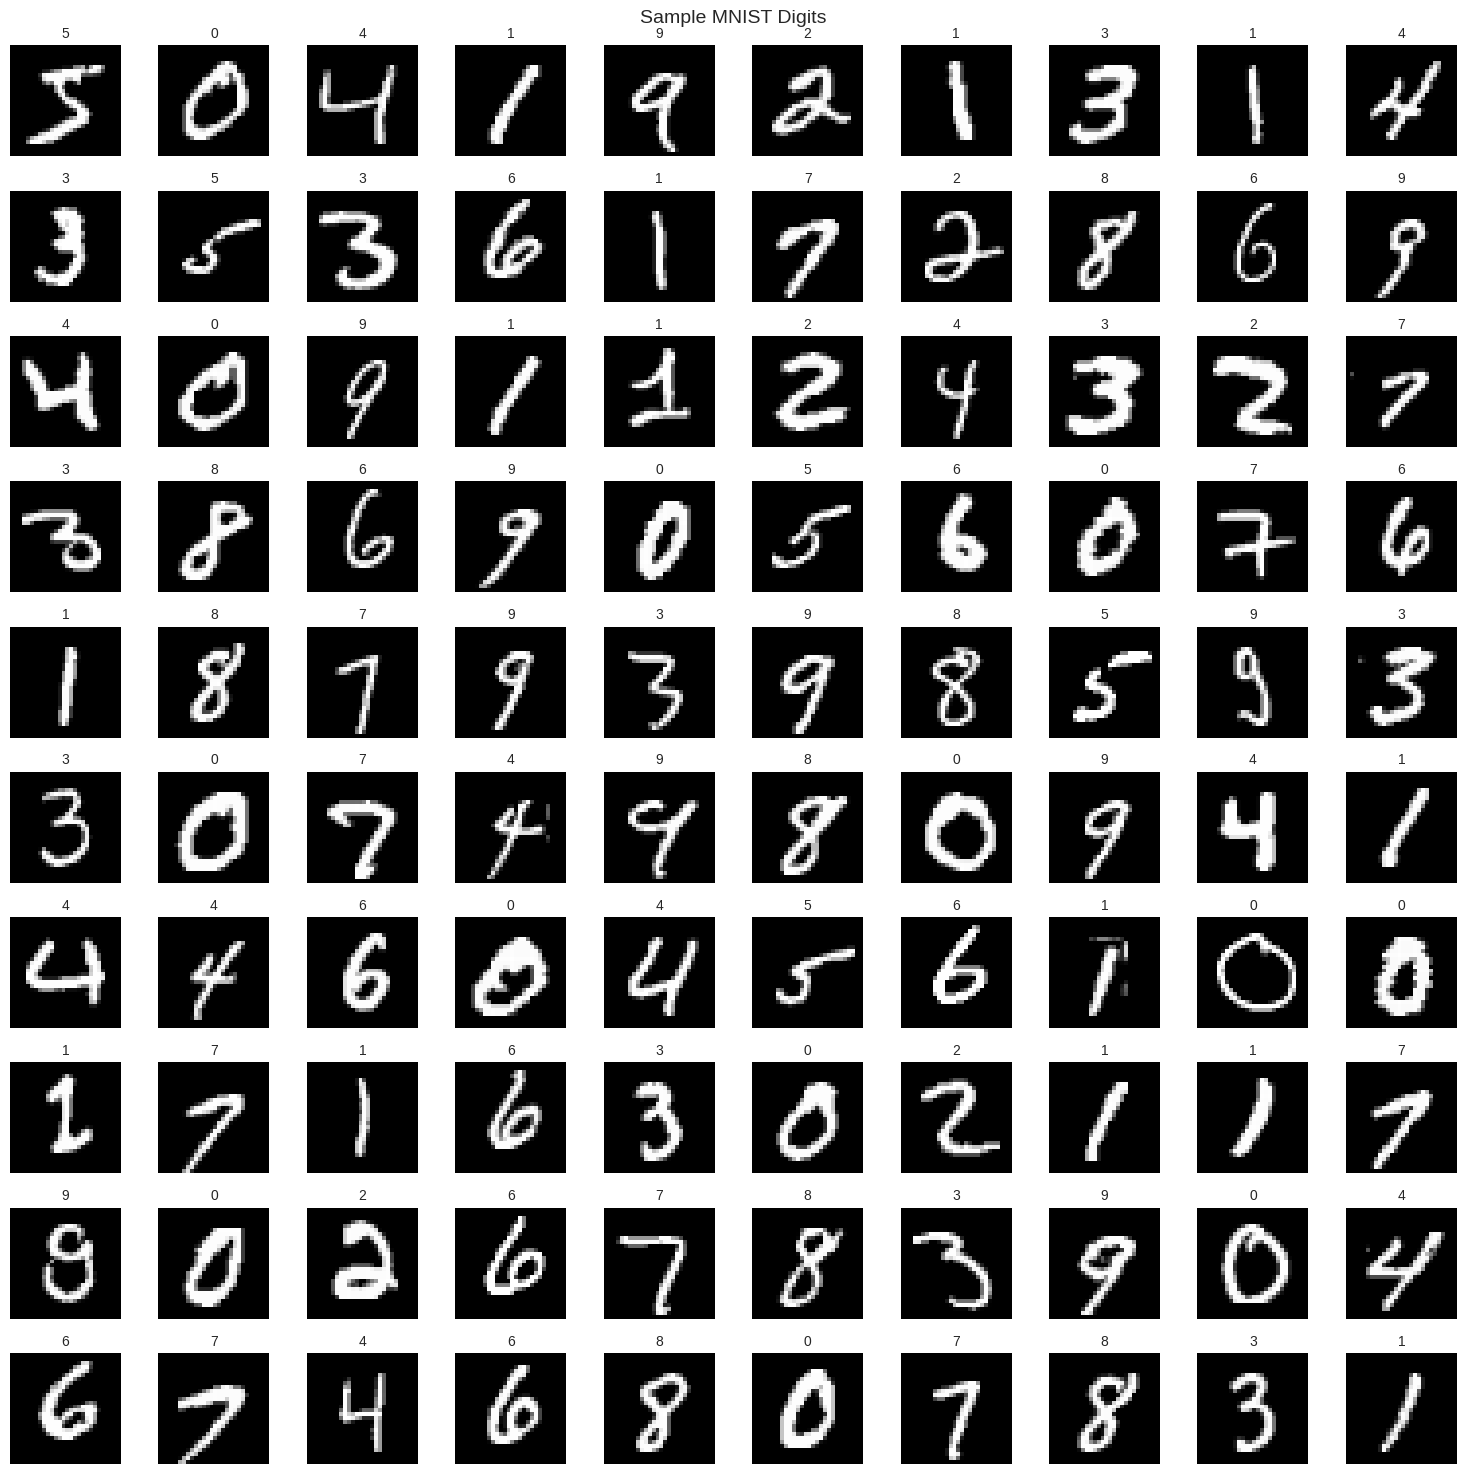

In [35]:
# Load MNIST dataset
(X_train_mnist, y_train_mnist), (X_test_mnist, y_test_mnist) = mnist.load_data()

print(f"Training set: {X_train_mnist.shape}")
print(f"Test set: {X_test_mnist.shape}")
print(f"Pixel range: [{X_train_mnist.min()}, {X_train_mnist.max()}]")

# Visualize samples
fig, axes = plt.subplots(10, 10, figsize=(15, 15))
for i in range(100):
    ax = axes[i // 10, i % 10]
    ax.imshow(X_train_mnist[i], cmap='gray')
    ax.set_title(f'{y_train_mnist[i]}', fontsize=10)
    ax.axis('off')
plt.suptitle('Sample MNIST Digits', fontsize=14)
plt.tight_layout()
plt.show()

In [37]:
# Explore the data structure in detail
print("="*60)
print("MNIST Data Structure")
print("="*60)

print("\n1. Data Types:")
print(f"   X_train_mnist type: {type(X_train_mnist)}")
print(f"   y_train_mnist type: {type(y_train_mnist)}")
print(f"   X_train_mnist dtype: {X_train_mnist.dtype}")
print(f"   y_train_mnist dtype: {y_train_mnist.dtype}")

print("\n2. Shapes:")
print(f"   X_train_mnist.shape: {X_train_mnist.shape}")
print(f"   → {X_train_mnist.shape[0]} images, each {X_train_mnist.shape[1]}×{X_train_mnist.shape[2]} pixels")
print(f"   y_train_mnist.shape: {y_train_mnist.shape}")

print("\n3. Value Ranges:")
print(f"   Pixel values: [{X_train_mnist.min()}, {X_train_mnist.max()}]")
print(f"   Labels: {np.unique(y_train_mnist)}")

print("\n4. Memory Usage:")
print(f"   X_train_mnist: {X_train_mnist.nbytes / 1024**2:.2f} MB")
print(f"   Total features per image: {X_train_mnist.shape[1] * X_train_mnist.shape[2]} pixels")

print("\n5. Example: First Digit (a '{0}')".format(y_train_mnist[0]))
print(f"   Shape: {X_train_mnist[0].shape}")
print(f"   First 5 rows of pixel values:")
print(X_train_mnist[0][:5])
print(f"   Non-zero pixels: {np.count_nonzero(X_train_mnist[0])} / {X_train_mnist[0].size}")

print("\n6. Label Distribution:")
unique, counts = np.unique(y_train_mnist, return_counts=True)
for digit, count in zip(unique, counts):
    print(f"   Digit {digit}: {count} samples ({count/len(y_train_mnist)*100:.1f}%)")

print("="*60)

MNIST Data Structure

1. Data Types:
   X_train_mnist type: <class 'numpy.ndarray'>
   y_train_mnist type: <class 'numpy.ndarray'>
   X_train_mnist dtype: uint8
   y_train_mnist dtype: uint8

2. Shapes:
   X_train_mnist.shape: (60000, 28, 28)
   → 60000 images, each 28×28 pixels
   y_train_mnist.shape: (60000,)

3. Value Ranges:
   Pixel values: [0, 255]
   Labels: [0 1 2 3 4 5 6 7 8 9]

4. Memory Usage:
   X_train_mnist: 44.86 MB
   Total features per image: 784 pixels

5. Example: First Digit (a '5')
   Shape: (28, 28)
   First 5 rows of pixel values:
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]
   Non-zero pixels: 166 / 784

6. Label Distribution:
   Digit 0: 5923 samples (9.9%)
   Digit 1: 6742 samples (11.2%)
   Digit 2: 5958 samples 

### Softmax and Categorical Cross-Entropy

For multi-class classification ($K$ classes):

Softmax: For each sample, convert logits to probabilities
$$\hat{y}_k = \frac{e^{z_k}}{\sum_{j=1}^K e^{z_j}}$$

where $z_k = w_k^T\phi(x)$ are the logits for class $k=1,\ldots,K$.

Categorical Cross-Entropy: Average over all $N$ training samples
$$L = -\frac{1}{N}\sum_{n=1}^N\sum_{k=1}^K y_{nk}\log(\hat{y}_{nk})$$

where $y_{nk} \in \{0,1\}$ is 1 if sample $n$ belongs to class $k$, and 0 otherwise.

In [38]:
# Preprocess data for linear model
X_train_flat = X_train_mnist.reshape(60000, 784).astype('float32') / 255.0
X_test_flat = X_test_mnist.reshape(10000, 784).astype('float32') / 255.0

# Use subset for faster training
n_samples = 10000
X_train_subset = X_train_flat[:n_samples]
y_train_subset = y_train_mnist[:n_samples]

# Train logistic regression (softmax for multi-class)
print("Training linear model (Softmax Regression)...")
linear_classifier = LogisticRegression(max_iter=100, solver='saga', verbose=1)
linear_classifier.fit(X_train_subset, y_train_subset)

# Evaluate
train_acc = linear_classifier.score(X_train_subset, y_train_subset)
test_acc = linear_classifier.score(X_test_flat, y_test_mnist)

Training linear model (Softmax Regression)...
Epoch 1, change: 1
Epoch 2, change: 0.17412214
Epoch 3, change: 0.12000103
Epoch 4, change: 0.087355576
Epoch 5, change: 0.066958934
Epoch 6, change: 0.054855719
Epoch 7, change: 0.052626375
Epoch 8, change: 0.048477549
Epoch 9, change: 0.043878045
Epoch 10, change: 0.042221475
Epoch 11, change: 0.039350837
Epoch 12, change: 0.037312739
Epoch 13, change: 0.034245949
Epoch 14, change: 0.032881863
Epoch 15, change: 0.031434204
Epoch 16, change: 0.029857844
Epoch 17, change: 0.027935574
Epoch 18, change: 0.02693934
Epoch 19, change: 0.026557693
Epoch 20, change: 0.025237285
Epoch 21, change: 0.023330659
Epoch 22, change: 0.022518009
Epoch 23, change: 0.021786302
Epoch 24, change: 0.020632036
Epoch 25, change: 0.019789042
Epoch 26, change: 0.019270768
Epoch 27, change: 0.017842637
Epoch 28, change: 0.017504504
Epoch 29, change: 0.016920045
Epoch 30, change: 0.015508709
Epoch 31, change: 0.015360652
Epoch 32, change: 0.014944104
Epoch 33, change

Training linear model (Softmax Regression)...
Epoch 1, change: 1
Epoch 2, change: 0.17412214
Epoch 3, change: 0.12000103
Epoch 4, change: 0.087355576
Epoch 5, change: 0.066958934
Epoch 6, change: 0.054855719
Epoch 7, change: 0.052626375
Epoch 8, change: 0.048477549
Epoch 9, change: 0.043878045
Epoch 10, change: 0.042221475
Epoch 11, change: 0.039350837
Epoch 12, change: 0.037312739
Epoch 13, change: 0.034245949
Epoch 14, change: 0.032881863
Epoch 15, change: 0.031434204
Epoch 16, change: 0.029857844
Epoch 17, change: 0.027935574
Epoch 18, change: 0.02693934
Epoch 19, change: 0.026557693
Epoch 20, change: 0.025237285
Epoch 21, change: 0.023330659
Epoch 22, change: 0.022518009
Epoch 23, change: 0.021786302
Epoch 24, change: 0.020632036
Epoch 25, change: 0.019789042
Epoch 26, change: 0.019270768
Epoch 27, change: 0.017842637
Epoch 28, change: 0.017504504
Epoch 29, change: 0.016920045
Epoch 30, change: 0.015508709
Epoch 31, change: 0.015360652
Epoch 32, change: 0.014944104
Epoch 33, change

/home/aythami-beth/ml/modelizacion/.modelizacion_env/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


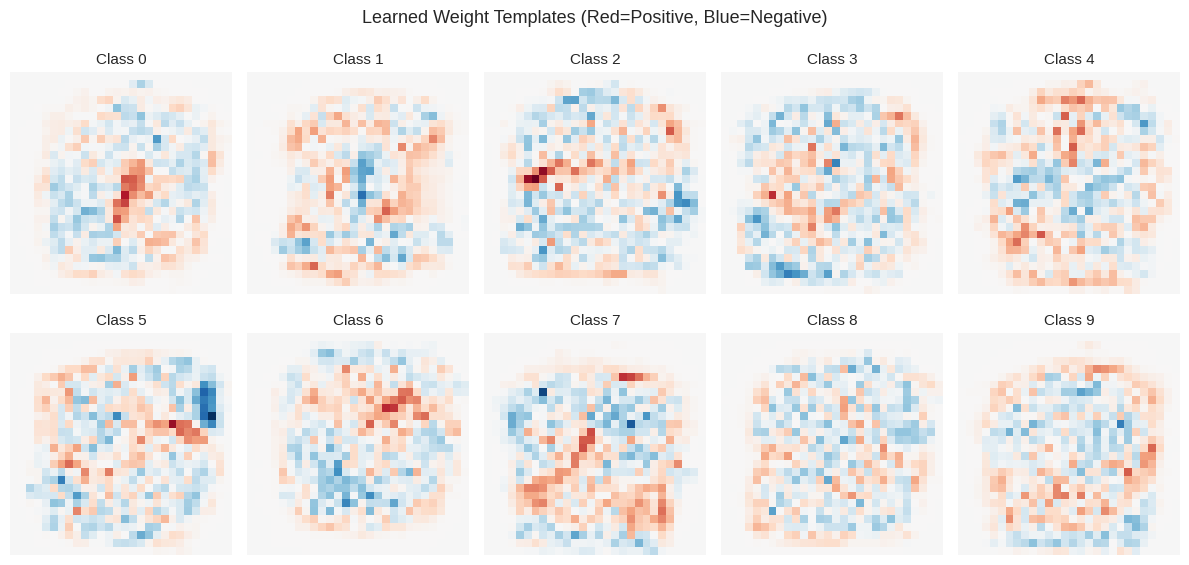

In [39]:
# Visualize learned weights
weights = linear_classifier.coef_.reshape(10, 28, 28)

fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i in range(10):
    ax = axes[i // 5, i % 5]
    im = ax.imshow(weights[i], cmap='RdBu', vmin=-weights.max(), vmax=weights.max())
    ax.set_title(f'Class {i}', fontsize=11)
    ax.axis('off')

plt.suptitle('Learned Weight Templates (Red=Positive, Blue=Negative)', fontsize=13)
plt.tight_layout()
plt.show()

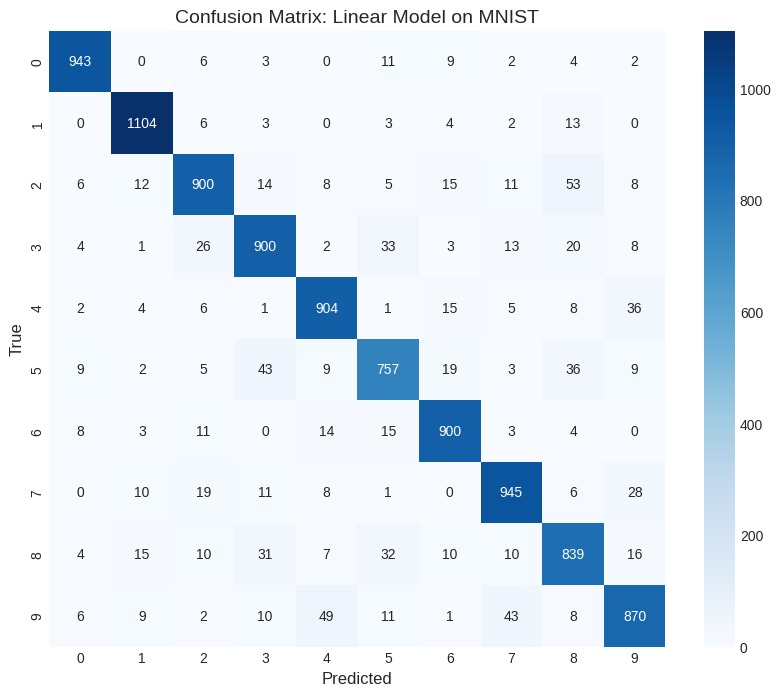


Most confused pairs:
  2 ↔ 8: 63 errors
  3 ↔ 5: 76 errors
  3 ↔ 8: 51 errors
  4 ↔ 9: 85 errors
  5 ↔ 8: 68 errors
  7 ↔ 9: 71 errors


In [40]:
# Confusion matrix
y_pred = linear_classifier.predict(X_test_flat)
cm = confusion_matrix(y_test_mnist, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', square=True)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.title('Confusion Matrix: Linear Model on MNIST', fontsize=14)
plt.show()

print("\nMost confused pairs:")
for i in range(10):
    for j in range(i+1, 10):
        if cm[i, j] + cm[j, i] > 50:
            print(f"  {i} ↔ {j}: {cm[i, j] + cm[j, i]} errors")

---
## 7. Multi-Layer Perceptrons: Breaking Linear Barriers

### The XOR Problem

XOR is not linearly separable. No linear model can solve it!

/home/aythami-beth/ml/modelizacion/.modelizacion_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1773979812.853133   51311 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1773979812.853477   52137 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1773979812.879425   51311 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed proper

/home/aythami-beth/ml/modelizacion/.modelizacion_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1773979812.853133   51311 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1773979812.853477   52137 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1773979812.879425   51311 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed proper

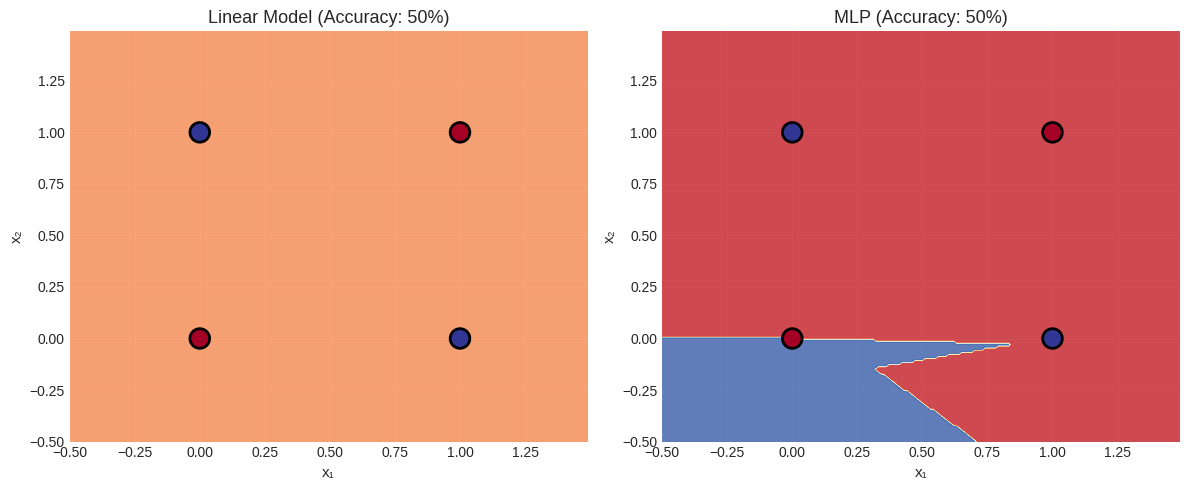


✓ MLP can learn non-linear decision boundaries!


In [41]:
# XOR dataset
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])

# Try logistic regression
log_reg_xor = LogisticRegression()
log_reg_xor.fit(X_xor, y_xor)
acc_linear_xor = log_reg_xor.score(X_xor, y_xor)

# Build a simple MLP with TensorFlow
mlp_xor = keras.Sequential([
    layers.Dense(4, activation='relu', input_shape=(2,)),
    layers.Dense(1, activation='sigmoid')
])

mlp_xor.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
mlp_xor.fit(X_xor, y_xor, epochs=500, verbose=0)

acc_mlp_xor = mlp_xor.evaluate(X_xor, y_xor, verbose=0)[1]

# Visualize decision boundaries
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Create mesh
h = 0.01
x_min, x_max = -0.5, 1.5
y_min, y_max = -0.5, 1.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Linear model
Z1 = log_reg_xor.predict(np.c_[xx.ravel(), yy.ravel()])
Z1 = Z1.reshape(xx.shape)
ax1.contourf(xx, yy, Z1, alpha=0.8, cmap='RdYlBu')
ax1.scatter(X_xor[:, 0], X_xor[:, 1], c=y_xor, s=200,
           edgecolors='black', linewidth=2, cmap='RdYlBu')
ax1.set_title(f'Linear Model (Accuracy: {acc_linear_xor:.0%})', fontsize=13)
ax1.set_xlabel('x₁', fontsize=11)
ax1.set_ylabel('x₂', fontsize=11)

# MLP
Z2 = mlp_xor.predict(np.c_[xx.ravel(), yy.ravel()], verbose=0)
Z2 = (Z2 > 0.5).astype(int).reshape(xx.shape)
ax2.contourf(xx, yy, Z2, alpha=0.8, cmap='RdYlBu')
ax2.scatter(X_xor[:, 0], X_xor[:, 1], c=y_xor, s=200,
           edgecolors='black', linewidth=2, cmap='RdYlBu')
ax2.set_title(f'MLP (Accuracy: {acc_mlp_xor:.0%})', fontsize=13)
ax2.set_xlabel('x₁', fontsize=11)
ax2.set_ylabel('x₂', fontsize=11)

plt.tight_layout()
plt.show()

print("\n✓ MLP can learn non-linear decision boundaries!")

### ReLU Activation

Modern MLPs typically use ReLU (Rectified Linear Unit):

$$\text{ReLU}(z) = \max(0, z)$$

/tmp/ipykernel_51311/903503816.py:28: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/home/aythami-beth/ml/modelizacion/.modelizacion_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


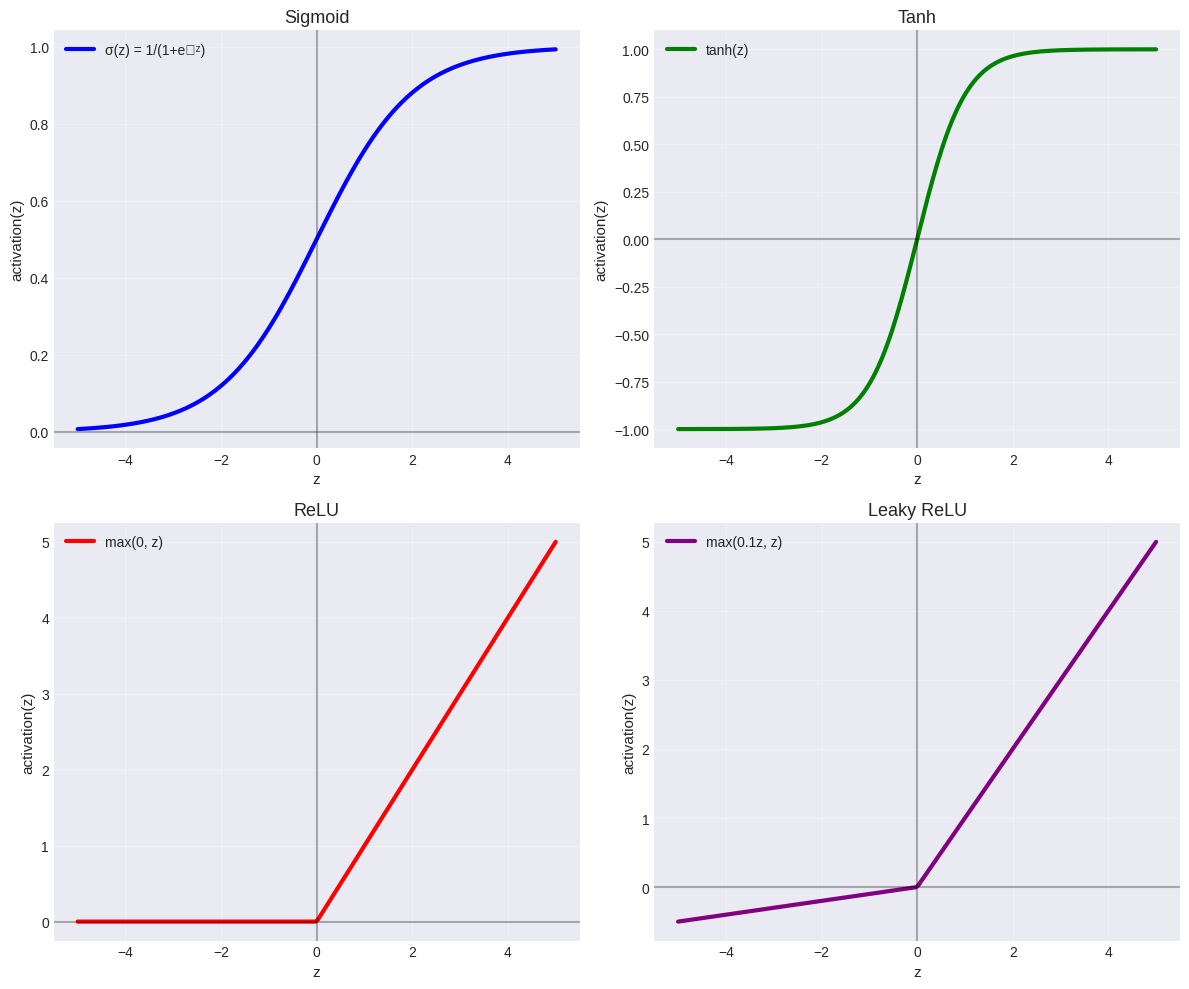

In [42]:
# Compare activation functions
z = np.linspace(-5, 5, 200)
sigmoid_act = 1 / (1 + np.exp(-z))
tanh_act = np.tanh(z)
relu_act = np.maximum(0, z)
leaky_relu_act = np.where(z > 0, z, 0.1*z)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

activations = [
    (sigmoid_act, 'Sigmoid', 'σ(z) = 1/(1+e⁻ᶻ)', 'blue'),
    (tanh_act, 'Tanh', 'tanh(z)', 'green'),
    (relu_act, 'ReLU', 'max(0, z)', 'red'),
    (leaky_relu_act, 'Leaky ReLU', 'max(0.1z, z)', 'purple')
]

for idx, (act, name, formula, color) in enumerate(activations):
    ax = axes[idx // 2, idx % 2]
    ax.plot(z, act, color=color, linewidth=3, label=formula)
    ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    ax.axvline(x=0, color='k', linestyle='-', alpha=0.3)
    ax.set_xlabel('z', fontsize=11)
    ax.set_ylabel('activation(z)', fontsize=11)
    ax.set_title(name, fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### MLP on MNIST

Let's see how an MLP dramatically improves performance on MNIST.

In [44]:
# Prepare data for neural network
X_train_nn = X_train_mnist.reshape(60000, 784).astype('float32') / 255.0
X_test_nn = X_test_mnist.reshape(10000, 784).astype('float32') / 255.0
y_train_cat = to_categorical(y_train_mnist, 10)
y_test_cat = to_categorical(y_test_mnist, 10)

# First, train a baseline linear model for comparison
print("=== Baseline: Linear Model (Softmax Regression) ===")
linear_baseline = LogisticRegression(max_iter=100, solver='saga', verbose=0)
# Use subset for faster training
linear_baseline.fit(X_train_nn[:10000], y_train_mnist[:10000])
test_acc_linear = linear_baseline.score(X_test_nn, y_test_mnist)
print(f"Linear model test accuracy: {test_acc_linear:.2%}\n")

# Build MLP
mlp_mnist = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

mlp_mnist.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("=== MLP Architecture ===")
mlp_mnist.summary()

print("\nTraining MLP...")
history = mlp_mnist.fit(
    X_train_nn, y_train_cat,
    validation_split=0.1,
    epochs=10,
    batch_size=128,
    verbose=1
)

# Evaluate
test_loss, test_acc = mlp_mnist.evaluate(X_test_nn, y_test_cat, verbose=0)
print(f"\n=== Final Results ===")
print(f"Linear Model: {test_acc_linear:.2%}")
print(f"MLP:          {test_acc:.2%}")
print(f"Improvement:  +{(test_acc - test_acc_linear)*100:.1f}%")

=== Baseline: Linear Model (Softmax Regression) ===
Linear model test accuracy: 90.62%

=== MLP Architecture ===


=== Baseline: Linear Model (Softmax Regression) ===
Linear model test accuracy: 90.62%

=== MLP Architecture ===


/home/aythami-beth/ml/modelizacion/.modelizacion_env/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/aythami-beth/ml/modelizacion/.modelizacion_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)


Training MLP...
Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9000 - loss: 0.3505 - val_accuracy: 0.9623 - val_loss: 0.1358
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9575 - loss: 0.1448 - val_accuracy: 0.9678 - val_loss: 0.1076
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9700 - loss: 0.1008 - val_accuracy: 0.9718 - val_loss: 0.0998
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9778 - loss: 0.0751 - val_accuracy: 0.9728 - val_loss: 0.0919
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9834 - loss: 0.0579 - val_accuracy: 0.9732 - val_loss: 0.0864
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9875 - loss: 0.0448 - val_accuracy: 0.9735 - val_loss: 0.0834
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9906 - loss: 0.0351 - val_accuracy: 0.9747 - val_loss: 0.0841
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9931 - loss: 0.0276 -

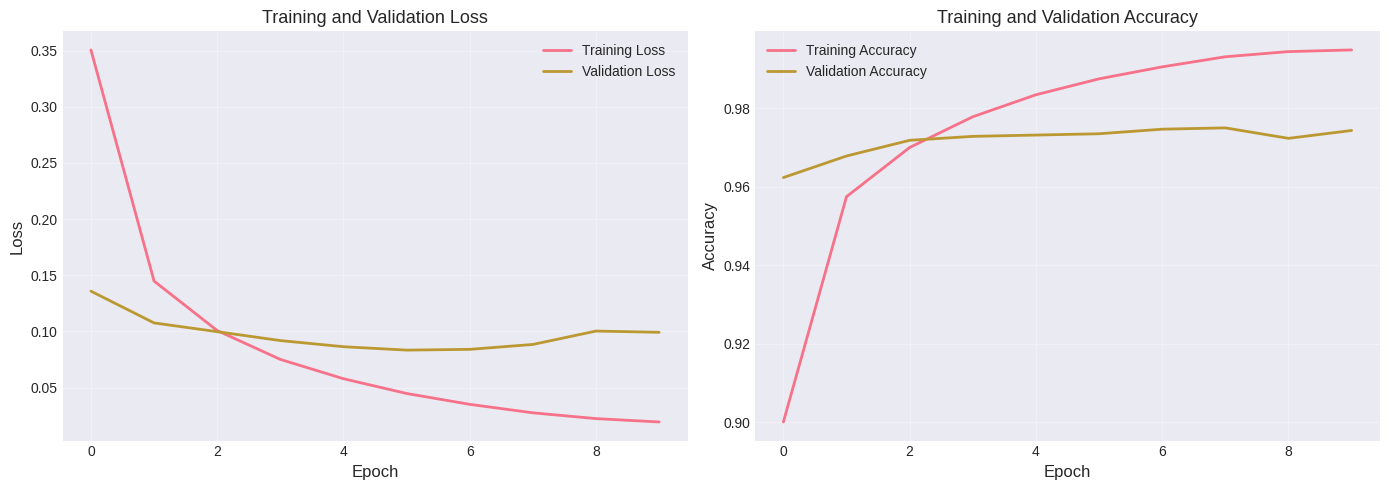

In [45]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(history.history['loss'], label='Training Loss', linewidth=2)
ax1.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training and Validation Loss', fontsize=13)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Training and Validation Accuracy', fontsize=13)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Visualizing Predictions

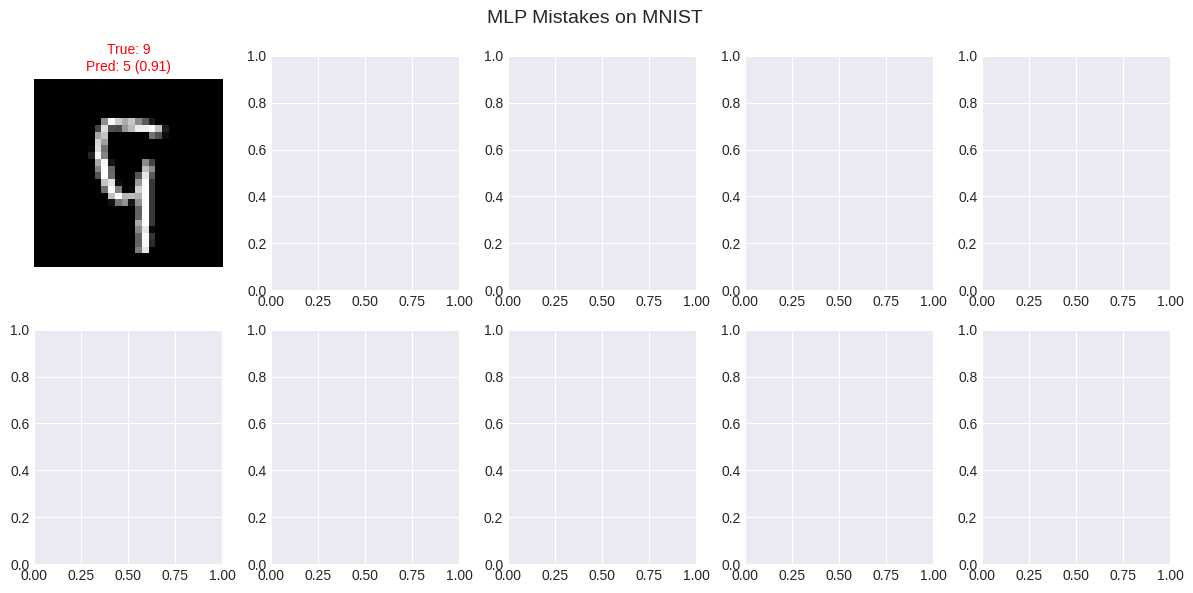

In [46]:
# Show some predictions
predictions = mlp_mnist.predict(X_test_nn[:100], verbose=0)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = y_test_mnist[:100]

# Find some mistakes
mistakes = np.where(predicted_classes != true_classes)[0]

if len(mistakes) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(12, 6))
    for i, idx in enumerate(mistakes[:10]):
        ax = axes[i // 5, i % 5]
        ax.imshow(X_test_mnist[idx], cmap='gray')
        true_label = true_classes[idx]
        pred_label = predicted_classes[idx]
        confidence = predictions[idx][pred_label]
        ax.set_title(f'True: {true_label}\nPred: {pred_label} ({confidence:.2f})',
                    fontsize=10, color='red')
        ax.axis('off')
    plt.suptitle('MLP Mistakes on MNIST', fontsize=14)
    plt.tight_layout()
    plt.show()

---
## 8. Universal Function Approximation

Universal Approximation Theorem: A neural network with a single hidden layer can approximate any continuous function to arbitrary precision.

Let's demonstrate this by approximating complex functions.

### Approximating sin(x) with MLPs

/home/aythami-beth/ml/modelizacion/.modelizacion_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/aythami-beth/ml/modelizacion/.modelizacion_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/aythami-beth/ml/modelizacion/.modelizacion_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)

/home/aythami-beth/ml/modelizacion/.modelizacion_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/aythami-beth/ml/modelizacion/.modelizacion_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/aythami-beth/ml/modelizacion/.modelizacion_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)

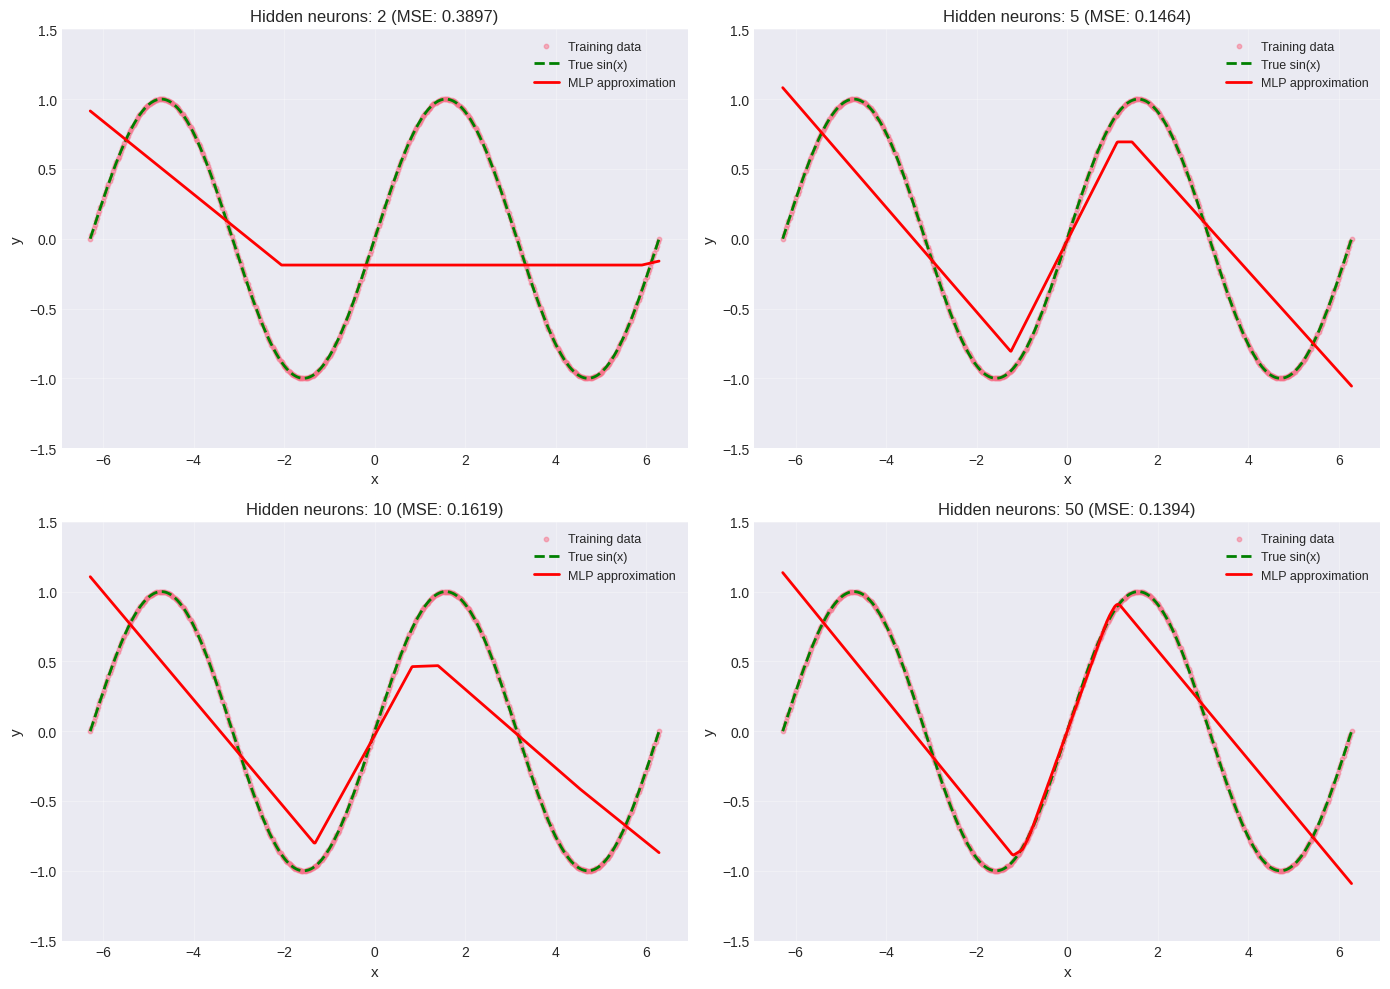

In [48]:
# Generate training data
X_func = np.linspace(-2*np.pi, 2*np.pi, 500).reshape(-1, 1)
y_func_sin = np.sin(X_func).ravel()

# Test different hidden layer sizes
hidden_sizes = [2, 5, 10, 50]
X_test_func = np.linspace(-2*np.pi, 2*np.pi, 1000).reshape(-1, 1)
y_test_true = np.sin(X_test_func).ravel()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, hidden_size in enumerate(hidden_sizes):
    # Build MLP
    model = keras.Sequential([
        layers.Dense(hidden_size, activation='relu', input_shape=(1,)),
        layers.Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse')
    model.fit(X_func, y_func_sin, epochs=200, verbose=0)

    # Predict
    y_pred = model.predict(X_test_func, verbose=0).ravel()
    mse = mean_squared_error(y_test_true, y_pred)

    # Plot
    axes[idx].scatter(X_func, y_func_sin, alpha=0.5, s=10, label='Training data')
    axes[idx].plot(X_test_func, y_test_true, 'g--', linewidth=2, label='True sin(x)')
    axes[idx].plot(X_test_func, y_pred, 'r-', linewidth=2, label='MLP approximation')
    axes[idx].set_xlabel('x', fontsize=11)
    axes[idx].set_ylabel('y', fontsize=11)
    axes[idx].set_title(f'Hidden neurons: {hidden_size} (MSE: {mse:.4f})', fontsize=12)
    axes[idx].legend(fontsize=9)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_ylim(-1.5, 1.5)

plt.tight_layout()
plt.show()

=== Effect of Network Depth ===



/home/aythami-beth/ml/modelizacion/.modelizacion_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/aythami-beth/ml/modelizacion/.modelizacion_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/aythami-beth/ml/modelizacion/.modelizacion_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)

=== Effect of Network Depth ===



/home/aythami-beth/ml/modelizacion/.modelizacion_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/aythami-beth/ml/modelizacion/.modelizacion_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/aythami-beth/ml/modelizacion/.modelizacion_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)

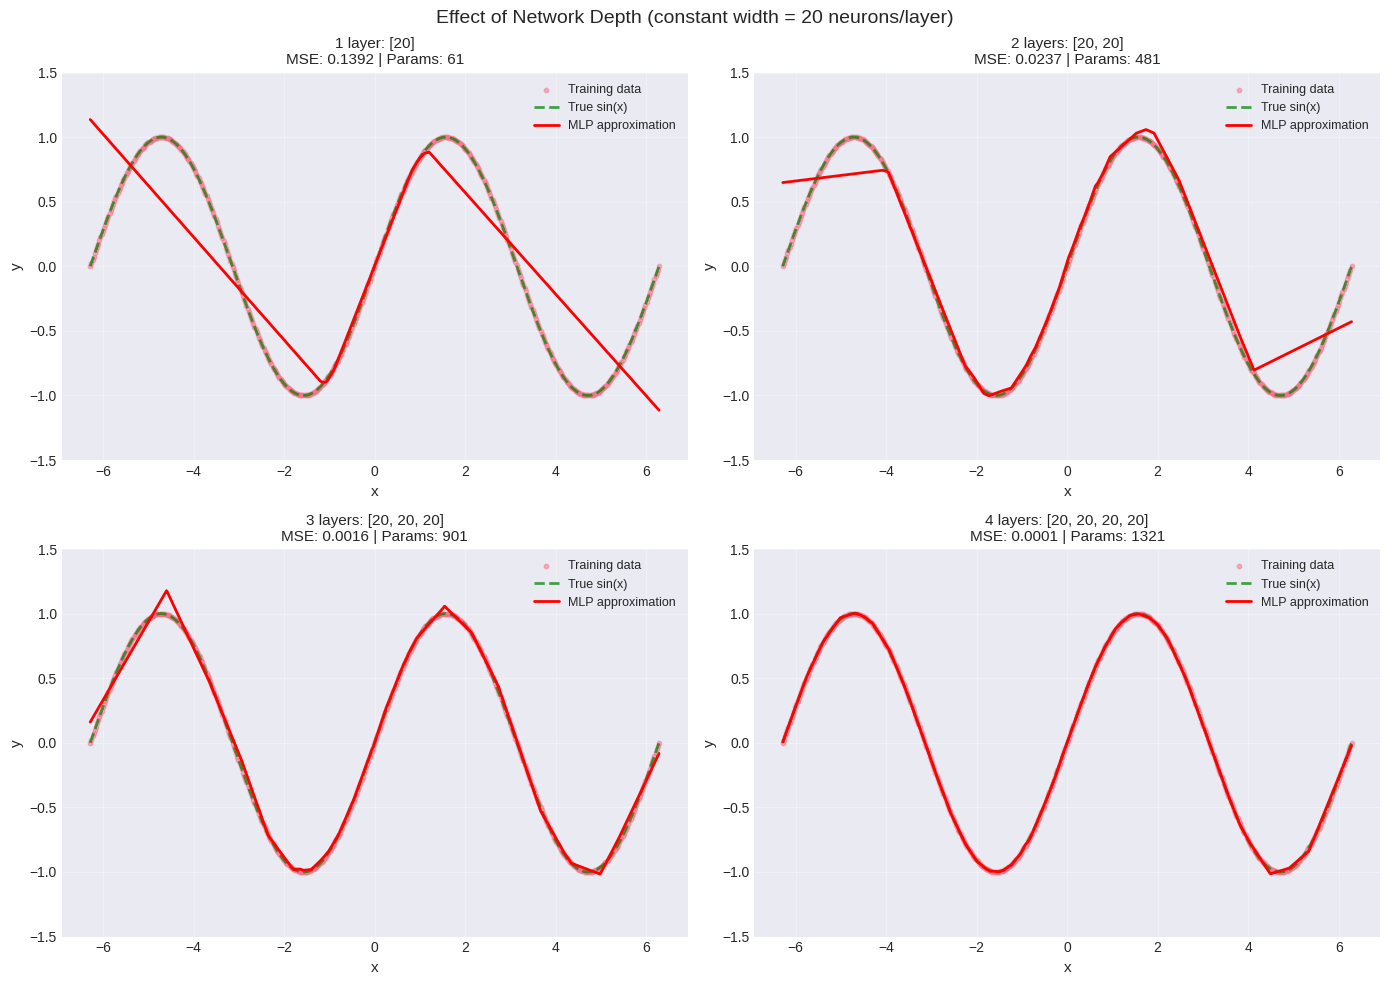


Key Observation:
• Deeper networks can learn complex functions with fewer total parameters
• But too deep → harder to train (vanishing gradients)
• Width vs Depth trade-off is problem-dependent


In [49]:
# Now test different depths (number of layers)
# Keep width constant at 20 neurons per layer, vary depth
print("=== Effect of Network Depth ===\n")

architectures = [
    ([20], "1 layer: [20]"),
    ([20, 20], "2 layers: [20, 20]"),
    ([20, 20, 20], "3 layers: [20, 20, 20]"),
    ([20, 20, 20, 20], "4 layers: [20, 20, 20, 20]")
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, (hidden_layers, desc) in enumerate(architectures):
    # Build MLP with variable depth
    model = keras.Sequential()
    model.add(layers.Dense(hidden_layers[0], activation='relu', input_shape=(1,)))

    for units in hidden_layers[1:]:
        model.add(layers.Dense(units, activation='relu'))

    model.add(layers.Dense(1))  # Output layer

    model.compile(optimizer='adam', loss='mse')
    history = model.fit(X_func, y_func_sin, epochs=200, verbose=0)

    # Predict
    y_pred = model.predict(X_test_func, verbose=0).ravel()
    mse = mean_squared_error(y_test_true, y_pred)
    final_loss = history.history['loss'][-1]

    # Count total parameters
    total_params = model.count_params()

    # Plot
    axes[idx].scatter(X_func, y_func_sin, alpha=0.5, s=10, label='Training data')
    axes[idx].plot(X_test_func, y_test_true, 'g--', linewidth=2, label='True sin(x)', alpha=0.7)
    axes[idx].plot(X_test_func, y_pred, 'r-', linewidth=2, label='MLP approximation')
    axes[idx].set_xlabel('x', fontsize=11)
    axes[idx].set_ylabel('y', fontsize=11)
    axes[idx].set_title(f'{desc}\nMSE: {mse:.4f} | Params: {total_params}', fontsize=11)
    axes[idx].legend(fontsize=9)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_ylim(-1.5, 1.5)

plt.suptitle('Effect of Network Depth (constant width = 20 neurons/layer)', fontsize=14)
plt.tight_layout()
plt.show()

### 8 Comparing Polynomial Features vs Learned Features

/home/aythami-beth/ml/modelizacion/.modelizacion_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


/home/aythami-beth/ml/modelizacion/.modelizacion_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


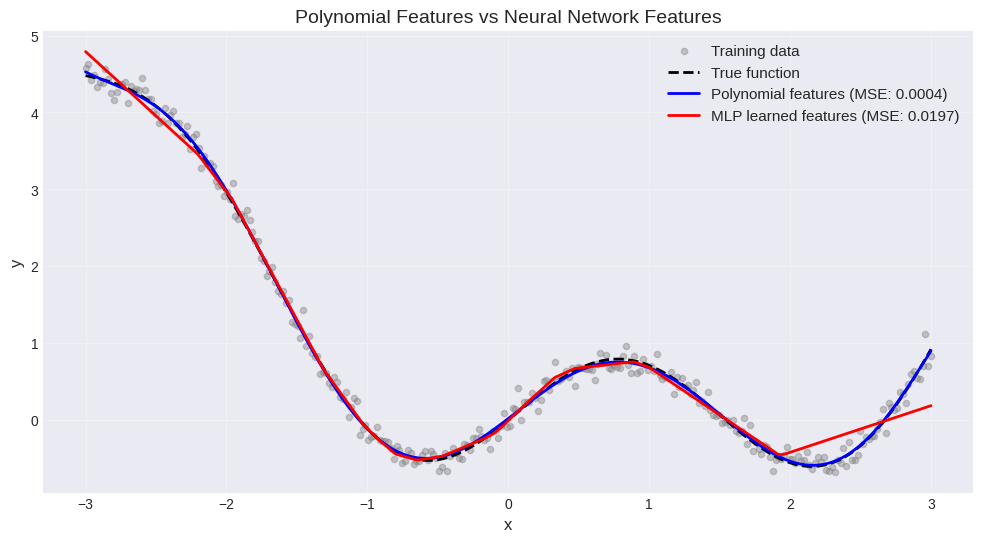


=== Comparison ===
Polynomial features (degree 10): 11 parameters, MSE = 0.0004
MLP (2 hidden layers):           481 parameters, MSE = 0.0197

Key insight: MLPs learn optimal features automatically!


In [50]:
# Complex function: combination of sin and polynomial
def complex_function(x):
    return np.sin(2*x) + 0.3*x**2 - 0.5*x

X_complex = np.linspace(-3, 3, 300).reshape(-1, 1)
y_complex = complex_function(X_complex).ravel() + np.random.normal(0, 0.1, 300)

X_test_complex = np.linspace(-3, 3, 500).reshape(-1, 1)
y_test_complex = complex_function(X_test_complex).ravel()

# Method 1: Polynomial features + linear regression
poly = PolynomialFeatures(degree=10)
X_poly = poly.fit_transform(X_complex)
X_test_poly = poly.transform(X_test_complex)

model_poly = Ridge(alpha=0.1)
model_poly.fit(X_poly, y_complex)
y_pred_poly = model_poly.predict(X_test_poly)
mse_poly = mean_squared_error(y_test_complex, y_pred_poly)

# Method 2: MLP (learns its own features)
model_mlp = keras.Sequential([
    layers.Dense(20, activation='relu', input_shape=(1,)),
    layers.Dense(20, activation='relu'),
    layers.Dense(1)
])

model_mlp.compile(optimizer='adam', loss='mse')
model_mlp.fit(X_complex, y_complex, epochs=200, verbose=0)
y_pred_mlp = model_mlp.predict(X_test_complex, verbose=0).ravel()
mse_mlp = mean_squared_error(y_test_complex, y_pred_mlp)

# Visualization
plt.figure(figsize=(12, 6))
plt.scatter(X_complex, y_complex, alpha=0.4, s=20, label='Training data', color='gray')
plt.plot(X_test_complex, y_test_complex, 'k--', linewidth=2, label='True function')
plt.plot(X_test_complex, y_pred_poly, 'b-', linewidth=2,
        label=f'Polynomial features (MSE: {mse_poly:.4f})')
plt.plot(X_test_complex, y_pred_mlp, 'r-', linewidth=2,
        label=f'MLP learned features (MSE: {mse_mlp:.4f})')
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Polynomial Features vs Neural Network Features', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

print("\n=== Comparison ===")
print(f"Polynomial features (degree 10): {len(model_poly.coef_)} parameters, MSE = {mse_poly:.4f}")
print(f"MLP (2 hidden layers):           {model_mlp.count_params()} parameters, MSE = {mse_mlp:.4f}")
print("\nKey insight: MLPs learn optimal features automatically!")

### 8 2D Function Approximation

In [ ]:
# Create 2D function
def func_2d(x, y):
    return np.sin(np.sqrt(x**2 + y**2)) / (1 + np.sqrt(x**2 + y**2))

# Generate training data
n = 1000
X_2d_train = np.random.uniform(-5, 5, (n, 2))
y_2d_train = func_2d(X_2d_train[:, 0], X_2d_train[:, 1])

# Create test grid
x_range = np.linspace(-5, 5, 50)
y_range = np.linspace(-5, 5, 50)
X_grid, Y_grid = np.meshgrid(x_range, y_range)
Z_true = func_2d(X_grid, Y_grid)

# Train MLP
mlp_2d = keras.Sequential([
    layers.Dense(50, activation='relu', input_shape=(2,)),
    layers.Dense(50, activation='relu'),
    layers.Dense(1)
])

mlp_2d.compile(optimizer='adam', loss='mse')
mlp_2d.fit(X_2d_train, y_2d_train, epochs=100, verbose=0)

# Predict
X_test_2d = np.c_[X_grid.ravel(), Y_grid.ravel()]
Z_pred = mlp_2d.predict(X_test_2d, verbose=0).reshape(X_grid.shape)

# Visualize
fig = plt.figure(figsize=(16, 6))

ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_surface(X_grid, Y_grid, Z_true, cmap='viridis', alpha=0.9)
ax1.set_title('True Function', fontsize=13)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')

ax2 = fig.add_subplot(132, projection='3d')
ax2.plot_surface(X_grid, Y_grid, Z_pred, cmap='viridis', alpha=0.9)
ax2.set_title('MLP Approximation', fontsize=13)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('z')

ax3 = fig.add_subplot(133, projection='3d')
error = np.abs(Z_true - Z_pred)
ax3.plot_surface(X_grid, Y_grid, error, cmap='Reds', alpha=0.9)
ax3.set_title(f'Absolute Error\n(Mean: {error.mean():.4f})', fontsize=13)
ax3.set_xlabel('x')
ax3.set_ylabel('y')
ax3.set_zlabel('|error|')

plt.tight_layout()
plt.show()

print(f"\nMean Absolute Error: {error.mean():.5f}")
print(f"Max Absolute Error: {error.max():.5f}")
print("\n✓ MLPs can approximate complex multi-dimensional functions!")

---
## 9. Deep Learning on CIFAR-10

### 9.1 Loading CIFAR-10

CIFAR-10: 60,000 color images (32×32) in 10 classes

In [ ]:
# Load CIFAR-10
(X_train_cifar, y_train_cifar), (X_test_cifar, y_test_cifar) = cifar10.load_data()

# Normalize pixel values
X_train_cifar = X_train_cifar.astype('float32') / 255.0
X_test_cifar = X_test_cifar.astype('float32') / 255.0

# Convert labels
y_train_cifar_cat = to_categorical(y_train_cifar, 10)
y_test_cifar_cat = to_categorical(y_test_cifar, 10)

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print(f"Training set: {X_train_cifar.shape}")
print(f"Test set: {X_test_cifar.shape}")

# Visualize samples
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i in range(20):
    ax = axes[i // 10, i % 10]
    ax.imshow(X_train_cifar[i])
    ax.set_title(class_names[y_train_cifar[i][0]], fontsize=9)
    ax.axis('off')
plt.suptitle('Sample CIFAR-10 Images', fontsize=14)
plt.tight_layout()
plt.show()

### 9.2 Convolutional Neural Network (CNN)

For images, Convolutional layers are more effective than fully-connected layers:
- Local connectivity (spatial patterns)
- Weight sharing (translation invariance)
- Hierarchical feature learning

In [ ]:
# Build CNN
cnn_cifar = keras.Sequential([
    # Convolutional layers
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Dense layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

cnn_cifar.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n=== CNN Architecture ===")
cnn_cifar.summary()

In [ ]:
# Train (WARNING: This will take several minutes!)
print("\nTraining CNN on CIFAR-10...")
print("(This may take 5-10 minutes depending on your hardware)\n")

history_cifar = cnn_cifar.fit(
    X_train_cifar, y_train_cifar_cat,
    validation_split=0.1,
    epochs=20,
    batch_size=64,
    verbose=1
)

# Evaluate
test_loss, test_acc_cifar = cnn_cifar.evaluate(X_test_cifar, y_test_cifar_cat, verbose=0)
print(f"\n=== CIFAR-10 Results ===")
print(f"Test Accuracy: {test_acc_cifar:.2%}")

In [ ]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_cifar.history['loss'], label='Training Loss', linewidth=2)
ax1.plot(history_cifar.history['val_loss'], label='Validation Loss', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('CIFAR-10 Training Loss', fontsize=13)
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history_cifar.history['accuracy'], label='Training Accuracy', linewidth=2)
ax2.plot(history_cifar.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('CIFAR-10 Training Accuracy', fontsize=13)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Show predictions
n_show = 20
predictions_cifar = cnn_cifar.predict(X_test_cifar[:n_show], verbose=0)
predicted_classes_cifar = np.argmax(predictions_cifar, axis=1)
true_classes_cifar = y_test_cifar[:n_show].ravel()

fig, axes = plt.subplots(4, 5, figsize=(12, 10))
axes = axes.ravel()

for i in range(n_show):
    axes[i].imshow(X_test_cifar[i])
    true_label = class_names[true_classes_cifar[i]]
    pred_label = class_names[predicted_classes_cifar[i]]
    confidence = predictions_cifar[i][predicted_classes_cifar[i]]

    color = 'green' if true_classes_cifar[i] == predicted_classes_cifar[i] else 'red'
    axes[i].set_title(f'T: {true_label}\nP: {pred_label} ({confidence:.2f})',
                     fontsize=9, color=color)
    axes[i].axis('off')

plt.suptitle('CNN Predictions on CIFAR-10 (Green=Correct, Red=Wrong)', fontsize=14)
plt.tight_layout()
plt.show()

---
## 10. Real-World Applications

### 10.1 Medical Diagnosis: Breast Cancer Classification

Let's apply MLPs to a real medical dataset. The Wisconsin Breast Cancer dataset contains features computed from cell nuclei images to predict whether a tumor is malignant or benign.

In [ ]:
# Load breast cancer dataset
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

# Load data
data = load_breast_cancer()
X_cancer = data.data
y_cancer = data.target

print(f"Dataset shape: {X_cancer.shape}")
print(f"Features: {data.feature_names[:5]}... ({len(data.feature_names)} total)")
print(f"Classes: {data.target_names}")
print(f"Class distribution: Malignant={np.sum(y_cancer==0)}, Benign={np.sum(y_cancer==1)}")

# Split and normalize
X_train_cancer, X_test_cancer, y_train_cancer, y_test_cancer = train_test_split(
    X_cancer, y_cancer, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_cancer_scaled = scaler.fit_transform(X_train_cancer)
X_test_cancer_scaled = scaler.transform(X_test_cancer)

In [ ]:
# Compare Linear vs MLP
# 1. Logistic Regression
log_reg_cancer = LogisticRegression(max_iter=1000)
log_reg_cancer.fit(X_train_cancer_scaled, y_train_cancer)
y_pred_log = log_reg_cancer.predict(X_test_cancer_scaled)
acc_log_cancer = accuracy_score(y_test_cancer, y_pred_log)

# 2. MLP
mlp_cancer = keras.Sequential([
    layers.Dense(32, activation='relu', input_shape=(30,)),
    layers.Dropout(0.3),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

mlp_cancer.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_cancer = mlp_cancer.fit(
    X_train_cancer_scaled, y_train_cancer,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=0
)

# Evaluate MLP
y_pred_mlp = (mlp_cancer.predict(X_test_cancer_scaled, verbose=0) > 0.5).astype(int).ravel()
acc_mlp_cancer = accuracy_score(y_test_cancer, y_pred_mlp)

print(f"\\n=== Medical Diagnosis Results ===")
print(f"Logistic Regression Accuracy: {acc_log_cancer:.2%}")
print(f"MLP Accuracy:                 {acc_mlp_cancer:.2%}")
print(f"\\nThis could help save lives by improving early detection!")

In [ ]:
# Visualize confusion matrices
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression
cm_log = confusion_matrix(y_test_cancer, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', square=True, ax=ax1,
            xticklabels=data.target_names, yticklabels=data.target_names)
ax1.set_xlabel('Predicted', fontsize=11)
ax1.set_ylabel('True', fontsize=11)
ax1.set_title(f'Logistic Regression\\nAccuracy: {acc_log_cancer:.2%}', fontsize=12)

# MLP
cm_mlp = confusion_matrix(y_test_cancer, y_pred_mlp)
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Greens', square=True, ax=ax2,
            xticklabels=data.target_names, yticklabels=data.target_names)
ax2.set_xlabel('Predicted', fontsize=11)
ax2.set_ylabel('True', fontsize=11)
ax2.set_title(f'MLP\\nAccuracy: {acc_mlp_cancer:.2%}', fontsize=12)

plt.tight_layout()
plt.show()

print("\\nNote: In medical applications, minimizing false negatives")
print("(missing malignant cases) is often more critical than overall accuracy!")

### 10.2 The Mandelbrot Set: Can MLPs Learn Fractal Boundaries?

The Mandelbrot set is defined by: $z_{n+1} = z_n^2 + c$, where a complex number $c$ is in the set if the sequence remains bounded.

Challenge: Can an MLP learn to classify whether a point $(x, y)$ in the complex plane is inside or outside the Mandelbrot set, without being explicitly programmed with the iterative formula?

In [ ]:
# Generate Mandelbrot set labels
def is_in_mandelbrot(c, max_iter=50):
    """Check if complex number c is in Mandelbrot set"""
    z = 0
    for _ in range(max_iter):
        if abs(z) > 2:
            return 0  # Escaped, not in set
        z = z*z + c
    return 1  # Remained bounded, in set

# Generate training data
np.random.seed(42)
n_samples = 20000

# Sample points in the interesting region of complex plane
real = np.random.uniform(-2, 1, n_samples)
imag = np.random.uniform(-1.5, 1.5, n_samples)
X_mandel = np.column_stack([real, imag])

# Compute labels (this takes a moment...)
print("Computing Mandelbrot set membership...")
y_mandel = np.array([is_in_mandelbrot(complex(r, i)) for r, i in X_mandel])

print(f"Generated {n_samples} points")
print(f"In set: {np.sum(y_mandel==1)}, Outside: {np.sum(y_mandel==0)}")

# Split data
X_train_mandel, X_test_mandel, y_train_mandel, y_test_mandel = train_test_split(
    X_mandel, y_mandel, test_size=0.2, random_state=42
)

In [ ]:
# Train MLP to learn Mandelbrot set
mlp_mandel = keras.Sequential([
    layers.Dense(64, activation='tanh', input_shape=(2,)),
    layers.Dense(64, activation='tanh'),
    layers.Dense(32, activation='tanh'),
    layers.Dense(1, activation='sigmoid')
])

mlp_mandel.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Training MLP on Mandelbrot set...")
history_mandel = mlp_mandel.fit(
    X_train_mandel, y_train_mandel,
    validation_split=0.2,
    epochs=30,
    batch_size=128,
    verbose=1
)

# Evaluate
test_acc_mandel = mlp_mandel.evaluate(X_test_mandel, y_test_mandel, verbose=0)[1]
print(f"\\nTest Accuracy: {test_acc_mandel:.2%}")

In [ ]:
# Visualize: True Mandelbrot vs MLP Approximation
resolution = 400
real_range = np.linspace(-2, 1, resolution)
imag_range = np.linspace(-1.5, 1.5, resolution)
Real, Imag = np.meshgrid(real_range, imag_range)

# True Mandelbrot set
print("Computing true Mandelbrot set (this takes a moment)...")
Z_true = np.array([[is_in_mandelbrot(complex(r, i)) for r in real_range]
                   for i in imag_range])

# MLP prediction
print("Computing MLP approximation...")
grid_points = np.column_stack([Real.ravel(), Imag.ravel()])
Z_pred = mlp_mandel.predict(grid_points, verbose=0).reshape(Real.shape)

# Visualization
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# True Mandelbrot
im1 = ax1.imshow(Z_true, extent=[-2, 1, -1.5, 1.5], origin='lower',
                 cmap='twilight', interpolation='bilinear')
ax1.set_xlabel('Real axis', fontsize=11)
ax1.set_ylabel('Imaginary axis', fontsize=11)
ax1.set_title('True Mandelbrot Set', fontsize=13)
ax1.grid(True, alpha=0.3)

# MLP approximation
im2 = ax2.imshow(Z_pred, extent=[-2, 1, -1.5, 1.5], origin='lower',
                 cmap='twilight', interpolation='bilinear')
ax2.set_xlabel('Real axis', fontsize=11)
ax2.set_ylabel('Imaginary axis', fontsize=11)
ax2.set_title(f'MLP Approximation (Acc: {test_acc_mandel:.1%})', fontsize=13)
ax2.grid(True, alpha=0.3)

# Difference
diff = np.abs(Z_true - (Z_pred > 0.5).astype(int))
im3 = ax3.imshow(diff, extent=[-2, 1, -1.5, 1.5], origin='lower',
                 cmap='Reds', interpolation='bilinear')
ax3.set_xlabel('Real axis', fontsize=11)
ax3.set_ylabel('Imaginary axis', fontsize=11)
ax3.set_title('Prediction Errors', fontsize=13)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✨ The MLP learned to approximate the fractal boundary!")
print("Notice: The network captures the overall structure but struggles with fine details.")

### 10.3 Physics: Predicting Pendulum Motion

Can an MLP learn the physics of a pendulum without knowing Newton's laws? Let's train a network to predict the angular position $\theta(t)$ given initial conditions.

For a simple pendulum: $\frac{d^2\theta}{dt^2} + \frac{g}{L}\sin(\theta) = 0$

In [ ]:
# Generate pendulum training data
from scipy.integrate import odeint

def pendulum_equations(state, t, g=9.8, L=1.0):
    """Pendulum differential equations"""
    theta, omega = state
    dtheta_dt = omega
    domega_dt = -(g/L) * np.sin(theta)
    return [dtheta_dt, domega_dt]

# Generate trajectories for different initial conditions
np.random.seed(42)
n_trajectories = 200
t_span = np.linspace(0, 10, 100)

X_pendulum = []
y_pendulum = []

for _ in range(n_trajectories):
    # Random initial angle and velocity
    theta0 = np.random.uniform(-np.pi, np.pi)
    omega0 = np.random.uniform(-2, 2)

    # Solve ODE
    solution = odeint(pendulum_equations, [theta0, omega0], t_span)
    theta_trajectory = solution[:, 0]

    # Create training samples: (t, theta0, omega0) -> theta(t)
    for i, t in enumerate(t_span):
        X_pendulum.append([t, theta0, omega0])
        y_pendulum.append(theta_trajectory[i])

X_pendulum = np.array(X_pendulum)
y_pendulum = np.array(y_pendulum)

print(f"Generated {len(X_pendulum)} training samples from {n_trajectories} trajectories")

# Split data
X_train_pend, X_test_pend, y_train_pend, y_test_pend = train_test_split(
    X_pendulum, y_pendulum, test_size=0.2, random_state=42
)

In [ ]:
# Train MLP to learn pendulum dynamics
mlp_pendulum = keras.Sequential([
    layers.Dense(64, activation='tanh', input_shape=(3,)),
    layers.Dense(64, activation='tanh'),
    layers.Dense(32, activation='tanh'),
    layers.Dense(1)
])

mlp_pendulum.compile(optimizer='adam', loss='mse')

print("Training MLP on pendulum dynamics...")
history_pend = mlp_pendulum.fit(
    X_train_pend, y_train_pend,
    validation_split=0.2,
    epochs=50,
    batch_size=128,
    verbose=0
)

# Evaluate
test_loss_pend = mlp_pendulum.evaluate(X_test_pend, y_test_pend, verbose=0)
print(f"Test MSE: {test_loss_pend:.6f}")

In [ ]:
# Test on new initial conditions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

test_conditions = [
    (np.pi/4, 0, "Small angle, no velocity"),
    (np.pi/2, 0, "90° release"),
    (0, 1.5, "Zero angle, with velocity"),
    (np.pi*0.8, -1, "Large angle, negative velocity")
]

for idx, (theta0, omega0, title) in enumerate(test_conditions):
    # True solution
    solution_true = odeint(pendulum_equations, [theta0, omega0], t_span)
    theta_true = solution_true[:, 0]

    # MLP prediction
    X_pred = np.array([[t, theta0, omega0] for t in t_span])
    theta_pred = mlp_pendulum.predict(X_pred, verbose=0).ravel()

    # Plot
    axes[idx].plot(t_span, theta_true, 'b-', linewidth=2, label='True (Physics)')
    axes[idx].plot(t_span, theta_pred, 'r--', linewidth=2, label='MLP Prediction')
    axes[idx].set_xlabel('Time (s)', fontsize=11)
    axes[idx].set_ylabel('θ (radians)', fontsize=11)
    axes[idx].set_title(f'{title}\\nθ₀={theta0:.2f}, ω₀={omega0:.1f}', fontsize=11)
    axes[idx].legend(fontsize=9)
    axes[idx].grid(True, alpha=0.3)

    # Calculate error
    mse = mean_squared_error(theta_true, theta_pred)
    axes[idx].text(0.02, 0.98, f'MSE: {mse:.4f}',
                  transform=axes[idx].transAxes, fontsize=9,
                  verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("\n🎯 The MLP learned pendulum physics from data!")
print("Notice: The network generalizes to initial conditions it hasn't seen before.")

---
## 11. Summary and Best Practices

### When to Use What?

| Problem Type | Best Approach | Why? |
|-------------|---------------|------|
| Linear relationship, small data | Linear/Ridge Regression | Simple, interpretable, exact solution |
| Non-linear, engineered features | Ridge Regression + Polynomial features | Combines domain knowledge with regularization |
| Classification, linearly separable | Logistic Regression | Fast, probabilistic, interpretable |
| Complex patterns, enough data | MLP | Learns features automatically |
| Image data | CNN | Exploits spatial structure |
| Sequential data | RNN/LSTM/Transformer | Captures temporal dependencies |

### Key Takeaways

1. Linear models are powerful with good feature engineering
2. Regularization prevents overfitting (always use it!)
3. MLPs can approximate any function (Universal Approximation)
4. Deep learning excels when:
   - Data is abundant
   - Patterns are complex
   - Features are hard to engineer manually
5. Always validate on held-out test data
6. Start simple, increase complexity only if needed

### Training Tips

- Normalize inputs: $\frac{x - \mu}{\sigma}$
- Use train/val/test splits: 60/20/20 or 70/15/15
- Monitor validation loss: Stop if it starts increasing
- Learning rate: Start with 0.001 (Adam optimizer)
- Batch size: 32-128 for most problems
- Dropout: 0.2-0.5 for regularization in deep networks

In [ ]:
# Summary visualization: Model complexity vs performance
models = ['Linear\nRegression', 'Ridge\nRegression', 'Polynomial\nFeatures',
          'Logistic\nRegression', 'Simple\nMLP', 'Deep\nMLP', 'CNN']
complexity = [1, 1.5, 3, 2, 5, 7, 9]
performance = [3, 4, 6, 5, 7, 8.5, 9.5]
data_need = [1, 1, 2, 2, 5, 8, 10]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Complexity vs Performance
colors = plt.cm.viridis(np.linspace(0, 1, len(models)))
ax1.scatter(complexity, performance, s=300, c=colors, alpha=0.7, edgecolors='black', linewidth=2)
for i, model in enumerate(models):
    ax1.annotate(model, (complexity[i], performance[i]),
                ha='center', va='center', fontsize=9, fontweight='bold')
ax1.set_xlabel('Model Complexity', fontsize=12)
ax1.set_ylabel('Performance Potential', fontsize=12)
ax1.set_title('Model Complexity vs Performance', fontsize=13)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)

# Data requirements
ax2.barh(models, data_need, color=colors, edgecolor='black', linewidth=1.5)
ax2.set_xlabel('Data Volume Required', fontsize=12)
ax2.set_title('Data Requirements by Model Type', fontsize=13)
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("   CONGRATULATIONS! You've completed the ML journey!")
print("="*60)
print("\nYou've learned:")
print("  ✓ Linear regression with arbitrary features")
print("  ✓ Regularization (L² / Ridge)")
print("  ✓ Gradient descent optimization")
print("  ✓ Binary and multi-class classification")
print("  ✓ Multi-layer perceptrons (MLPs)")
print("  ✓ Universal function approximation")
print("  ✓ Deep learning on real datasets (MNIST, CIFAR-10)")
print("\nKeep exploring and happy learning! 🚀")

---
## Further Exploration

To deepen your knowledge:

1. Experiment with different architectures and hyperparameters
2. Try other datasets: Fashion-MNIST, ImageNet subsets
3. Learn about:
   - Convolutional architectures (ResNet, VGG)
   - Batch normalization and layer normalization
   - Advanced optimizers (AdamW, SGD with momentum)
   - Transfer learning
   - Data augmentation
4. Read papers on arXiv.org
5. Participate in Kaggle competitions

Remember: The best way to learn is by doing! 🎓